# CLIP Prefix Captioning - Training Notebook for Kaggle

This notebook trains the CLIP prefix captioning model on Kaggle using the HuggingFace COCO dataset.

**Requirements:**
- GPU enabled (Settings → Accelerator → GPU T4 x2 or P100)
- Internet enabled (Settings → Internet → On)

**Data Source:**
- Uses HuggingFace dataset: `yerevann/coco-karpathy`
- Automatically downloads and preprocesses the data
- Extracts CLIP features from images

**Model Options:**
- MLP mapping with GPT-2 fine-tuning (default)
- Transformer mapping with frozen GPT-2


In [1]:
# Install required packages
%pip install transformers ftfy regex tqdm scikit-image datasets pillow requests
%pip install git+https://github.com/openai/CLIP.git
%pip install nltk pycocotools rouge-score matplotlib seaborn mlflow

import sys
print("Python version:", sys.version)
print("Packages installed successfully!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 38.6 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 19.0.1
    Uninstalling pyarrow-19.0.1:
      Successfully uninstalled pyarrow-19.0.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
pylibcudf-cu12 25.2.2 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 22.0.0 which is incompatible.
cudf-cu12 25.2.2 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 22.0.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
cudf-polars-cu12 25.6.0 requires pyli

In [2]:
# Import all necessary libraries
import torch
import torch.nn as nn
from torch.nn import functional as nnf
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from enum import Enum
from transformers import GPT2Tokenizer, GPT2LMHeadModel, get_linear_schedule_with_warmup
from tqdm import tqdm
import os
import pickle
import json
from typing import Tuple, Optional, Union, List, Dict
import numpy as np
import clip
from datasets import load_dataset
from PIL import Image
import requests
from io import BytesIO
import time
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from pycocotools.coco import COCO
try:
    from pycocotools.cocoeval import COCOeval
except ImportError:
    # Alternative import path
    try:
        from pycocoeval.cocoeval import COCOeval
    except ImportError:
        # If both fail, we'll define a dummy class
        print("Warning: COCOeval not available. CIDEr evaluation will be limited.")
        COCOeval = None
import warnings
warnings.filterwarnings('ignore')

# MLOps integration
try:
    import mlflow
    import mlflow.pytorch
    MLFLOW_AVAILABLE = True
    print("✓ MLflow available for experiment tracking")
except ImportError:
    MLFLOW_AVAILABLE = False
    print("⚠️  MLflow not available. Install with: pip install mlflow")

# Download NLTK data
try:
    nltk.download('punkt', quiet=True)
    nltk.download('wordnet', quiet=True)
    nltk.download('omw-1.4', quiet=True)
except:
    pass

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")


2025-12-07 10:55:29.560999: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765104929.730609      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765104929.779587      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

✓ MLflow available for experiment tracking
Using device: cuda
GPU: Tesla T4
CUDA Version: 12.4
GPU Memory: 15.83 GB


## Model Architecture Classes

All model classes from the original repository:


In [3]:
# ========== MODEL ARCHITECTURE ==========

class MappingType(Enum):
    MLP = 'mlp'
    Transformer = 'transformer'


class MLP(nn.Module):
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)

    def __init__(self, sizes: Tuple[int, ...], bias=True, act=nn.Tanh):
        super(MLP, self).__init__()
        layers = []
        for i in range(len(sizes) - 1):
            layers.append(nn.Linear(sizes[i], sizes[i + 1], bias=bias))
            if i < len(sizes) - 2:
                layers.append(act())
        self.model = nn.Sequential(*layers)


class MlpTransformer(nn.Module):
    def __init__(self, in_dim, h_dim, out_d: Optional[int] = None, act=nnf.relu, dropout=0.):
        super().__init__()
        out_d = out_d if out_d is not None else in_dim
        self.fc1 = nn.Linear(in_dim, h_dim)
        self.act = act
        self.fc2 = nn.Linear(h_dim, out_d)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.dropout(x)
        return x


class MultiHeadAttention(nn.Module):
    def __init__(self, dim_self, dim_ref, num_heads, bias=True, dropout=0.):
        super().__init__()
        self.num_heads = num_heads
        head_dim = dim_self // num_heads
        self.scale = head_dim ** -0.5
        self.to_queries = nn.Linear(dim_self, dim_self, bias=bias)
        self.to_keys_values = nn.Linear(dim_ref, dim_self * 2, bias=bias)
        self.project = nn.Linear(dim_self, dim_self)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, y=None, mask=None):
        y = y if y is not None else x
        b, n, c = x.shape
        _, m, d = y.shape
        queries = self.to_queries(x).reshape(b, n, self.num_heads, c // self.num_heads)
        keys_values = self.to_keys_values(y).reshape(b, m, 2, self.num_heads, c // self.num_heads)
        keys, values = keys_values[:, :, 0], keys_values[:, :, 1]
        attention = torch.einsum('bnhd,bmhd->bnmh', queries, keys) * self.scale
        if mask is not None:
            if mask.dim() == 2:
                mask = mask.unsqueeze(1)
            attention = attention.masked_fill(mask.unsqueeze(3), float("-inf"))
        attention = attention.softmax(dim=2)
        out = torch.einsum('bnmh,bmhd->bnhd', attention, values).reshape(b, n, c)
        out = self.project(out)
        return out, attention


class TransformerLayer(nn.Module):
    def forward_with_attention(self, x, y=None, mask=None):
        x_, attention = self.attn(self.norm1(x), y, mask)
        x = x + x_
        x = x + self.mlp(self.norm2(x))
        return x, attention

    def forward(self, x, y=None, mask=None):
        x = x + self.attn(self.norm1(x), y, mask)[0]
        x = x + self.mlp(self.norm2(x))
        return x

    def __init__(self, dim_self, dim_ref, num_heads, mlp_ratio=4., bias=False, dropout=0., act=nnf.relu,
                 norm_layer: nn.Module = nn.LayerNorm):
        super().__init__()
        self.norm1 = norm_layer(dim_self)
        self.attn = MultiHeadAttention(dim_self, dim_ref, num_heads, bias=bias, dropout=dropout)
        self.norm2 = norm_layer(dim_self)
        self.mlp = MlpTransformer(dim_self, int(dim_self * mlp_ratio), act=act, dropout=dropout)


class Transformer(nn.Module):
    def forward_with_attention(self, x, y=None, mask=None):
        attentions = []
        for layer in self.layers:
            x, att = layer.forward_with_attention(x, y, mask)
            attentions.append(att)
        return x, attentions

    def forward(self, x, y=None, mask=None):
        for i, layer in enumerate(self.layers):
            if i % 2 == 0 and self.enc_dec:
                x = layer(x, y)
            elif self.enc_dec:
                x = layer(x, x, mask)
            else:
                x = layer(x, y, mask)
        return x

    def __init__(self, dim_self: int, num_heads: int, num_layers: int, dim_ref: Optional[int] = None,
                 mlp_ratio: float = 2., act=nnf.relu, norm_layer: nn.Module = nn.LayerNorm, enc_dec: bool = False):
        super(Transformer, self).__init__()
        dim_ref = dim_ref if dim_ref is not None else dim_self
        self.enc_dec = enc_dec
        if enc_dec:
            num_layers = num_layers * 2
        layers = []
        for i in range(num_layers):
            if i % 2 == 0 and enc_dec:
                layers.append(TransformerLayer(dim_self, dim_ref, num_heads, mlp_ratio, act=act, norm_layer=norm_layer))
            elif enc_dec:
                layers.append(TransformerLayer(dim_self, dim_self, num_heads, mlp_ratio, act=act, norm_layer=norm_layer))
            else:
                layers.append(TransformerLayer(dim_self, dim_ref, num_heads, mlp_ratio, act=act, norm_layer=norm_layer))
        self.layers = nn.ModuleList(layers)


class TransformerMapper(nn.Module):
    def forward(self, x):
        x = self.linear(x).view(x.shape[0], self.clip_length, -1)
        prefix = self.prefix_const.unsqueeze(0).expand(x.shape[0], *self.prefix_const.shape)
        prefix = torch.cat((x, prefix), dim=1)
        out = self.transformer(prefix)[:, self.clip_length:]
        return out

    def __init__(self, dim_clip: int, dim_embedding: int, prefix_length: int, clip_length: int, num_layers: int = 8):
        super(TransformerMapper, self).__init__()
        self.clip_length = clip_length
        self.transformer = Transformer(dim_embedding, 8, num_layers)
        self.linear = nn.Linear(dim_clip, clip_length * dim_embedding)
        self.prefix_const = nn.Parameter(torch.randn(prefix_length, dim_embedding), requires_grad=True)


class ClipCaptionModel(nn.Module):
    def get_dummy_token(self, batch_size: int, device: torch.device) -> torch.Tensor:
        return torch.zeros(batch_size, self.prefix_length, dtype=torch.int64, device=device)

    def forward(self, tokens: torch.Tensor, prefix: torch.Tensor, mask: Optional[torch.Tensor] = None,
                labels: Optional[torch.Tensor] = None):
        embedding_text = self.gpt.transformer.wte(tokens)
        prefix_projections = self.clip_project(prefix).view(-1, self.prefix_length, self.gpt_embedding_size)
        embedding_cat = torch.cat((prefix_projections, embedding_text), dim=1)
        if labels is not None:
            dummy_token = self.get_dummy_token(tokens.shape[0], tokens.device)
            labels = torch.cat((dummy_token, tokens), dim=1)
        out = self.gpt(inputs_embeds=embedding_cat, labels=labels, attention_mask=mask)
        return out

    def __init__(self, prefix_length: int, clip_length: Optional[int] = None, prefix_size: int = 512,
                 num_layers: int = 8, mapping_type: MappingType = MappingType.MLP):
        super(ClipCaptionModel, self).__init__()
        self.prefix_length = prefix_length
        self.gpt = GPT2LMHeadModel.from_pretrained('gpt2')
        self.gpt_embedding_size = self.gpt.transformer.wte.weight.shape[1]
        if mapping_type == MappingType.MLP:
            self.clip_project = MLP((prefix_size, (self.gpt_embedding_size * prefix_length) // 2,
                                     self.gpt_embedding_size * prefix_length))
        else:
            self.clip_project = TransformerMapper(prefix_size, self.gpt_embedding_size, prefix_length,
                                                 clip_length, num_layers)


class ClipCaptionPrefix(ClipCaptionModel):
    def parameters(self, recurse: bool = True):
        return self.clip_project.parameters()

    def train(self, mode: bool = True):
        super(ClipCaptionPrefix, self).train(mode)
        self.gpt.eval()
        return self

print("Model classes defined successfully!")


Model classes defined successfully!


In [4]:
# ========== DATASET CLASS ==========

class ClipCocoDataset(Dataset):
    def __len__(self) -> int:
        return len(self.captions_tokens)

    def pad_tokens(self, item: int):
        tokens = self.captions_tokens[item]
        padding = self.max_seq_len - tokens.shape[0]
        if padding > 0:
            tokens = torch.cat((tokens, torch.zeros(padding, dtype=torch.int64) - 1))
            self.captions_tokens[item] = tokens
        elif padding < 0:
            tokens = tokens[:self.max_seq_len]
            self.captions_tokens[item] = tokens
        mask = tokens.ge(0)  # mask is zero where we out of sequence
        tokens[~mask] = 0
        mask = mask.float()
        mask = torch.cat((torch.ones(self.prefix_length), mask), dim=0)  # adding prefix mask
        return tokens, mask

    def __getitem__(self, item: int) -> Tuple[torch.Tensor, ...]:
        tokens, mask = self.pad_tokens(item)
        prefix = self.prefixes[self.caption2embedding[item]]
        # Ensure prefix is 1D tensor of shape [embedding_dim]
        if prefix.dim() > 1:
            prefix = prefix.flatten()
        elif prefix.dim() == 0:
            raise ValueError(f"Prefix has wrong shape: {prefix.shape}")
        if self.normalize_prefix:
            prefix = prefix.float()
            prefix = prefix / prefix.norm(2, -1)
        return tokens, mask, prefix

    def __init__(self, data_path: str, prefix_length: int, gpt2_type: str = "gpt2",
                 normalize_prefix=False):
        self.tokenizer = GPT2Tokenizer.from_pretrained(gpt2_type)
        self.prefix_length = prefix_length
        self.normalize_prefix = normalize_prefix
        
        print(f"Loading data from {data_path}...")
        with open(data_path, 'rb') as f:
            all_data = pickle.load(f)
        
        print(f"Data size is {len(all_data['clip_embedding'])}")
        
        self.prefixes = all_data["clip_embedding"]
        captions_raw = all_data["captions"]
        self.image_ids = [caption["image_id"] for caption in captions_raw]
        self.captions = [caption['caption'] for caption in captions_raw]
        
        # Check if tokenized data exists
        token_path = f"{data_path[:-4]}_tokens.pkl"
        if os.path.isfile(token_path):
            print(f"Loading tokenized data from {token_path}...")
            with open(token_path, 'rb') as f:
                self.captions_tokens, self.caption2embedding, self.max_seq_len = pickle.load(f)
        else:
            print("Tokenizing captions...")
            self.captions_tokens = []
            self.caption2embedding = []
            max_seq_len = 0
            for caption in tqdm(captions_raw, desc="Tokenizing"):
                self.captions_tokens.append(torch.tensor(self.tokenizer.encode(caption['caption']), dtype=torch.int64))
                self.caption2embedding.append(caption["clip_embedding"])
                max_seq_len = max(max_seq_len, self.captions_tokens[-1].shape[0])
            
            # Save tokenized data for future use
            print(f"Saving tokenized data to {token_path}...")
            with open(token_path, 'wb') as f:
                pickle.dump([self.captions_tokens, self.caption2embedding, max_seq_len], f)
        
        all_len = torch.tensor([len(self.captions_tokens[i]) for i in range(len(self))]).float()
        self.max_seq_len = min(int(all_len.mean() + all_len.std() * 10), int(all_len.max()))
        print(f"Max sequence length: {self.max_seq_len}")

print("Dataset class defined successfully!")


Dataset class defined successfully!


In [5]:
## Data Visualization Functions


In [6]:
# ========== DATA VISUALIZATION FUNCTIONS ==========

def visualize_dataset_statistics(captions_raw: List[Dict], dataset: Optional[ClipCocoDataset] = None):
    """Visualize dataset statistics including caption lengths, word frequencies, etc.
    
    Args:
        captions_raw: List of caption dictionaries with 'caption' and 'image_id' keys
        dataset: Optional ClipCocoDataset (not currently used, kept for compatibility)
    """
    
    # Caption length analysis
    caption_lengths = [len(caption['caption'].split()) for caption in captions_raw]
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Caption length distribution
    axes[0, 0].hist(caption_lengths, bins=50, edgecolor='black', alpha=0.7)
    axes[0, 0].set_xlabel('Caption Length (words)', fontsize=12)
    axes[0, 0].set_ylabel('Frequency', fontsize=12)
    axes[0, 0].set_title('Distribution of Caption Lengths', fontsize=14, fontweight='bold')
    axes[0, 0].axvline(np.mean(caption_lengths), color='r', linestyle='--', 
                       label=f'Mean: {np.mean(caption_lengths):.1f}')
    axes[0, 0].axvline(np.median(caption_lengths), color='g', linestyle='--', 
                       label=f'Median: {np.median(caption_lengths):.1f}')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Caption length box plot
    axes[0, 1].boxplot(caption_lengths, vert=True)
    axes[0, 1].set_ylabel('Caption Length (words)', fontsize=12)
    axes[0, 1].set_title('Caption Length Box Plot', fontsize=14, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Word frequency (top 20)
    all_words = []
    for caption in captions_raw:
        words = caption['caption'].lower().split()
        all_words.extend(words)
    
    word_freq = Counter(all_words)
    top_words = word_freq.most_common(20)
    words, freqs = zip(*top_words)
    
    axes[1, 0].barh(range(len(words)), freqs, color='steelblue')
    axes[1, 0].set_yticks(range(len(words)))
    axes[1, 0].set_yticklabels(words)
    axes[1, 0].set_xlabel('Frequency', fontsize=12)
    axes[1, 0].set_title('Top 20 Most Frequent Words', fontsize=14, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3, axis='x')
    
    # 4. Dataset statistics summary
    axes[1, 1].axis('off')
    stats_text = f"""
    Dataset Statistics:
    
    Total Captions: {len(captions_raw):,}
    Unique Images: {len(set(c['image_id'] for c in captions_raw)):,}
    Average Caption Length: {np.mean(caption_lengths):.2f} words
    Median Caption Length: {np.median(caption_lengths):.2f} words
    Min Caption Length: {np.min(caption_lengths)} words
    Max Caption Length: {np.max(caption_lengths)} words
    Std Dev: {np.std(caption_lengths):.2f} words
    
    Unique Words: {len(word_freq):,}
    Total Words: {len(all_words):,}
    """
    axes[1, 1].text(0.1, 0.5, stats_text, fontsize=12, 
                    verticalalignment='center', family='monospace',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    return {
        'caption_lengths': caption_lengths,
        'word_freq': word_freq,
        'stats': {
            'total_captions': len(captions_raw),
            'unique_images': len(set(c['image_id'] for c in captions_raw)),
            'avg_length': np.mean(caption_lengths),
            'median_length': np.median(caption_lengths),
            'unique_words': len(word_freq)
        }
    }

def visualize_sample_images(dataset_hf, num_samples=6):
    """Visualize sample images from the dataset"""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx in range(min(num_samples, len(dataset_hf))):
        sample = dataset_hf[idx]
        img_id = sample.get('imgid', sample.get('cocoid', idx))
        url = sample.get('url', '')
        sentences = sample.get('sentences', [])
        
        # Try to load image
        try:
            if url.startswith('http'):
                response = requests.get(url, timeout=5)
                img = Image.open(BytesIO(response.content))
            else:
                img = None
        except:
            img = None
        
        if img:
            axes[idx].imshow(img)
            axes[idx].axis('off')
            if sentences:
                caption = sentences[0] if isinstance(sentences[0], str) else str(sentences[0])
                axes[idx].set_title(caption[:80] + '...' if len(caption) > 80 else caption, 
                                  fontsize=10, pad=10)
        else:
            axes[idx].text(0.5, 0.5, f'Image {img_id}\n(Unable to load)', 
                          ha='center', va='center', fontsize=12)
            axes[idx].axis('off')
    
    plt.suptitle('Sample Images from Dataset', fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

print("Data visualization functions defined successfully!")


Data visualization functions defined successfully!


## Evaluation Metrics and Inference Functions


In [7]:
# ========== EVALUATION METRICS FUNCTIONS ==========

def calculate_bleu_scores(reference: List[str], candidate: str, max_n=4):
    """Calculate BLEU-1, BLEU-2, BLEU-3, BLEU-4 scores"""
    reference_tokens = [ref.lower().split() for ref in reference]
    candidate_tokens = candidate.lower().split()
    
    smoothing = SmoothingFunction().method1
    scores = {}
    
    for n in range(1, max_n + 1):
        try:
            score = sentence_bleu(reference_tokens, candidate_tokens, 
                                 weights=tuple([1/n] * n), smoothing_function=smoothing)
            scores[f'BLEU-{n}'] = score
        except:
            scores[f'BLEU-{n}'] = 0.0
    
    return scores

def calculate_meteor_score(reference: List[str], candidate: str):
    """Calculate METEOR score"""
    try:
        # METEOR requires tokenized sentences
        ref_tokens = [nltk.word_tokenize(ref.lower()) for ref in reference]
        cand_tokens = nltk.word_tokenize(candidate.lower())
        
        # Calculate METEOR for each reference and take the max
        meteor_scores = [meteor_score(ref, cand_tokens) for ref in ref_tokens]
        return max(meteor_scores) if meteor_scores else 0.0
    except:
        return 0.0

def calculate_rouge_scores(reference: List[str], candidate: str):
    """Calculate ROUGE-L score"""
    try:
        from rouge_score import rouge_scorer
        scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
        
        # Use the first reference or combine all
        ref_text = reference[0] if reference else ""
        scores = scorer.score(ref_text, candidate)
        return scores['rougeL'].fmeasure
    except:
        return 0.0

def calculate_cider_score(references: List[List[str]], candidates: List[str]):
    """Calculate CIDEr score using pycocotools with proper COCO format"""
    try:
        # Create temporary annotation file for COCO eval
        import tempfile
        
        # COCO format requires: {"images": [...], "annotations": [...], "categories": [...]}
        # Create images list
        images = []
        for idx in range(len(references)):
            images.append({
                "id": idx,
                "file_name": f"image_{idx}.jpg"  # Dummy filename
            })
        
        # Create reference annotations in COCO format
        ref_annotations = []
        ann_id = 0
        for img_id, refs in enumerate(references):
            for ref in refs:
                ref_annotations.append({
                    "id": ann_id,
                    "image_id": img_id,
                    "caption": ref
                })
                ann_id += 1
        
        # Create ground truth COCO format
        coco_gt_format = {
            "images": images,
            "annotations": ref_annotations,
            "categories": [{"id": 1, "name": "object"}]  # Dummy category for COCO format
        }
        
        # Create results in COCO format (predictions)
        results = []
        for idx, cand in enumerate(candidates):
            results.append({
                "image_id": idx,
                "caption": cand
            })
        
        # Save to temporary files
        with tempfile.NamedTemporaryFile(mode='w', suffix='.json', delete=False, encoding='utf-8') as f:
            json.dump(coco_gt_format, f, ensure_ascii=False)
            ref_file = f.name
        
        with tempfile.NamedTemporaryFile(mode='w', suffix='.json', delete=False, encoding='utf-8') as f:
            json.dump(results, f, ensure_ascii=False)
            results_file = f.name
        
        # Use COCO eval
        if COCOeval is None:
            print("COCOeval not available, skipping CIDEr calculation")
            os.unlink(results_file)
            os.unlink(ref_file)
            return 0.0
        
        coco_gt = COCO(ref_file)
        coco_dt = coco_gt.loadRes(results_file)
        
        coco_eval = COCOeval(coco_gt, coco_dt, 'CIDEr')
        coco_eval.evaluate()
        coco_eval.accumulate()
        coco_eval.summarize()
        
        cider_score = coco_eval.eval['CIDEr'][0] if 'CIDEr' in coco_eval.eval else 0.0
        
        # Cleanup
        os.unlink(results_file)
        os.unlink(ref_file)
        
        return cider_score
    except Exception as e:
        print(f"Error calculating CIDEr: {e}")
        import traceback
        traceback.print_exc()
        return 0.0

def evaluate_model(model: ClipCaptionModel, dataset: ClipCocoDataset, 
                  tokenizer: GPT2Tokenizer, device: torch.device, 
                  num_samples: int = 100, max_length: int = 77):
    """Evaluate model on dataset and return metrics"""
    model.eval()
    all_references = []
    all_candidates = []
    
    # Sample random indices
    indices = np.random.choice(len(dataset), min(num_samples, len(dataset)), replace=False)
    
    with torch.no_grad():
        for idx in tqdm(indices, desc="Evaluating"):
            tokens, mask, prefix = dataset[idx]
            tokens = tokens.unsqueeze(0).to(device)
            prefix = prefix.unsqueeze(0).to(device, dtype=torch.float32)
            
            # Generate caption
            generated = generate_caption(model, tokenizer, prefix, device, max_length)
            
            # Get reference
            reference = dataset.captions[idx]
            all_references.append([reference])  # List of references for each sample
            all_candidates.append(generated)
    
    # Calculate metrics
    metrics = {
        'BLEU-1': [],
        'BLEU-2': [],
        'BLEU-3': [],
        'BLEU-4': [],
        'METEOR': [],
        'ROUGE-L': []
    }
    
    for refs, cand in zip(all_references, all_candidates):
        bleu_scores = calculate_bleu_scores(refs[0] if isinstance(refs[0], list) else refs, cand)
        for key in bleu_scores:
            metrics[key].append(bleu_scores[key])
        
        meteor = calculate_meteor_score(refs[0] if isinstance(refs[0], list) else refs, cand)
        metrics['METEOR'].append(meteor)
        
        rouge = calculate_rouge_scores(refs[0] if isinstance(refs[0], list) else refs, cand)
        metrics['ROUGE-L'].append(rouge)
    
    # Calculate averages
    avg_metrics = {key: np.mean(values) for key, values in metrics.items()}
    
    # Calculate CIDEr (requires all samples)
    try:
        cider = calculate_cider_score(all_references, all_candidates)
        avg_metrics['CIDEr'] = cider
    except:
        avg_metrics['CIDEr'] = 0.0
    
    model.train()
    return avg_metrics, all_references, all_candidates

print("Evaluation metrics functions defined successfully!")


Evaluation metrics functions defined successfully!


In [8]:
# ========== INFERENCE AND GENERATION FUNCTIONS ==========

def generate_caption(model: ClipCaptionModel, tokenizer: GPT2Tokenizer, 
                    prefix: torch.Tensor, device: torch.device, 
                    max_length: int = 77, temperature: float = 1.0,
                    top_k: int = 0, top_p: float = 0.9):
    """Generate caption from CLIP prefix embedding"""
    model.eval()
    
    with torch.no_grad():
        prefix = prefix.to(device, dtype=torch.float32)
        
        # Project prefix to GPT embedding space
        prefix_projections = model.clip_project(prefix).view(-1, model.prefix_length, model.gpt_embedding_size)
        
        # Generate tokens
        generated_tokens = []
        generated_embeddings = prefix_projections
        
        # Start with beginning of sentence token
        tokenizer.pad_token = tokenizer.eos_token
        
        for _ in range(max_length):
            # Get logits from GPT
            outputs = model.gpt(inputs_embeds=generated_embeddings)
            logits = outputs.logits[:, -1, :] / temperature
            
            # Apply top-k and top-p filtering
            if top_k > 0:
                indices_to_remove = logits < torch.topk(logits, top_k)[0][..., -1, None]
                logits[indices_to_remove] = float('-inf')
            
            if top_p < 1.0:
                sorted_logits, sorted_indices = torch.sort(logits, descending=True)
                cumulative_probs = torch.cumsum(torch.softmax(sorted_logits, dim=-1), dim=-1)
                sorted_indices_to_remove = cumulative_probs > top_p
                sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
                sorted_indices_to_remove[..., 0] = 0
                indices_to_remove = sorted_indices_to_remove.scatter(1, sorted_indices, sorted_indices_to_remove)
                logits[indices_to_remove] = float('-inf')
            
            # Sample next token
            probs = torch.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            generated_tokens.append(next_token.item())
            
            # Check for end token
            if next_token.item() == tokenizer.eos_token_id or next_token.item() == tokenizer.pad_token_id:
                break
            
            # Get embedding for next token
            next_embedding = model.gpt.transformer.wte(next_token)
            # next_token is [batch_size, 1], so wte returns [batch_size, 1, embedding_dim]
            # Ensure next_embedding has shape [batch_size, 1, embedding_dim] for concatenation
            if next_embedding.dim() == 2:
                # If 2D [batch_size, embedding_dim], add sequence dimension
                next_embedding = next_embedding.unsqueeze(1)
            elif next_embedding.dim() == 3:
                # If already 3D, check if sequence dimension is correct
                if next_embedding.shape[1] > 1:
                    # If shape is [batch_size, seq_len, embedding_dim] where seq_len > 1, take last token
                    next_embedding = next_embedding[:, -1:, :]
                # If shape[1] == 1, it's already correct, use as is
            generated_embeddings = torch.cat([generated_embeddings, next_embedding], dim=1)
        
        # Decode tokens to text
        caption = tokenizer.decode(generated_tokens, skip_special_tokens=True)
        return caption.strip()

def generate_caption_from_image(model: ClipCaptionModel, tokenizer: GPT2Tokenizer,
                               clip_model, preprocess, image_path_or_url: str,
                               device: torch.device, max_length: int = 77):
    """Generate caption from image file or URL"""
    # Load and preprocess image
    try:
        if image_path_or_url.startswith('http'):
            response = requests.get(image_path_or_url, timeout=10)
            img = Image.open(BytesIO(response.content))
        else:
            img = Image.open(image_path_or_url)
        
        if img.mode != 'RGB':
            img = img.convert('RGB')
        
        # Extract CLIP features
        img_tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            clip_features = clip_model.encode_image(img_tensor).cpu().float()
        
        # Generate caption
        caption = generate_caption(model, tokenizer, clip_features, device, max_length)
        return caption, img
    except Exception as e:
        return f"Error: {e}", None

def generate_captions_batch(model: ClipCaptionModel, tokenizer: GPT2Tokenizer,
                           prefixes: torch.Tensor, device: torch.device,
                           max_length: int = 77):
    """Generate captions for a batch of prefix embeddings"""
    model.eval()
    captions = []
    
    for i in range(prefixes.shape[0]):
        prefix = prefixes[i:i+1]
        caption = generate_caption(model, tokenizer, prefix, device, max_length)
        captions.append(caption)
    
    return captions

print("Inference and generation functions defined successfully!")


Inference and generation functions defined successfully!


## Training Function


In [9]:
# ========== TRAINING FUNCTION WITH VALIDATION ==========

def validate_model(model: ClipCaptionModel, val_dataloader: DataLoader, device: torch.device):
    """Validate model on validation set"""
    model.eval()
    val_losses = []
    
    with torch.no_grad():
        for tokens, mask, prefix in val_dataloader:
            tokens = tokens.to(device)
            mask = mask.to(device)
            prefix = prefix.to(device, dtype=torch.float32)
            
            outputs = model(tokens, prefix, mask)
            logits = outputs.logits[:, model.prefix_length - 1: -1]
            loss = nnf.cross_entropy(logits.reshape(-1, logits.shape[-1]), tokens.flatten(), ignore_index=0)
            val_losses.append(loss.item())
    
    model.train()
    return np.mean(val_losses)

def train_model(dataset: ClipCocoDataset, model: ClipCaptionModel, 
                val_dataset: Optional[ClipCocoDataset] = None,
                epochs: int = 10, batch_size: int = 40, lr: float = 2e-5, 
                warmup_steps: int = 5000, output_dir: str = "./checkpoints", 
                output_prefix: str = "coco_prefix", save_every: int = 1,
                validate_every: int = 1):
    """
    Train the CLIP prefix captioning model with optional validation.
    
    Args:
        dataset: ClipCocoDataset instance for training
        model: ClipCaptionModel instance
        val_dataset: Optional ClipCocoDataset instance for validation
        epochs: Number of training epochs
        batch_size: Batch size for training
        lr: Learning rate
        warmup_steps: Number of warmup steps for learning rate scheduler
        output_dir: Directory to save checkpoints
        output_prefix: Prefix for saved checkpoint files
        save_every: Save checkpoint every N epochs
        validate_every: Validate every N epochs
    """
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    model = model.to(device)
    model.train()
    optimizer = AdamW(model.parameters(), lr=lr)
    train_dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    
    val_dataloader = None
    if val_dataset is not None:
        val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=False)
    
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=warmup_steps, num_training_steps=epochs * len(train_dataloader)
    )
    
    # Training history
    training_losses = []
    validation_losses = []
    
    print(f"\n{'='*60}")
    print(f"Starting Training")
    print(f"{'='*60}")
    print(f"Epochs: {epochs}")
    print(f"Batch Size: {batch_size}")
    print(f"Learning Rate: {lr}")
    print(f"Warmup Steps: {warmup_steps}")
    print(f"Total Steps: {epochs * len(train_dataloader)}")
    print(f"Validation: {'Yes' if val_dataset is not None else 'No'}")
    print(f"Output Directory: {output_dir}")
    print(f"{'='*60}\n")
    
    best_val_loss = float('inf')
    
    for epoch in range(epochs):
        print(f"\n>>> Training epoch {epoch + 1}/{epochs}")
        epoch_losses = []
        progress = tqdm(total=len(train_dataloader), desc=f"Epoch {epoch + 1}")
        
        for idx, (tokens, mask, prefix) in enumerate(train_dataloader):
            model.zero_grad()
            tokens = tokens.to(device)
            mask = mask.to(device)
            prefix = prefix.to(device, dtype=torch.float32)
            
            outputs = model(tokens, prefix, mask)
            logits = outputs.logits[:, dataset.prefix_length - 1: -1]
            loss = nnf.cross_entropy(logits.reshape(-1, logits.shape[-1]), tokens.flatten(), ignore_index=0)
            
            loss.backward()
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
            
            epoch_losses.append(loss.item())
            progress.set_postfix({"loss": f"{loss.item():.4f}", "avg_loss": f"{np.mean(epoch_losses):.4f}"})
            progress.update()
            
            # Save intermediate checkpoint every 10000 steps
            if (idx + 1) % 10000 == 0:
                checkpoint_path = os.path.join(output_dir, f"{output_prefix}_latest.pt")
                torch.save(model.state_dict(), checkpoint_path)
                print(f"\nIntermediate checkpoint saved: {checkpoint_path}")
        
        progress.close()
        avg_epoch_loss = np.mean(epoch_losses)
        training_losses.append(avg_epoch_loss)
        print(f"Epoch {epoch + 1} completed. Average Training Loss: {avg_epoch_loss:.4f}")
        
        # Validation
        if val_dataloader is not None and epoch % validate_every == 0:
            val_loss = validate_model(model, val_dataloader, device)
            validation_losses.append(val_loss)
            print(f"Validation Loss: {val_loss:.4f}")
            
            # Save best model
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_path = os.path.join(output_dir, f"{output_prefix}_best.pt")
                torch.save(model.state_dict(), best_model_path)
                print(f"✓ New best model saved (val_loss: {val_loss:.4f})")
        
        # Save checkpoint
        if epoch % save_every == 0 or epoch == epochs - 1:
            checkpoint_path = os.path.join(output_dir, f"{output_prefix}-{epoch+1:03d}.pt")
            torch.save(model.state_dict(), checkpoint_path)
            print(f"Checkpoint saved: {checkpoint_path}")
    
    # Save final model and training history
    final_path = os.path.join(output_dir, f"{output_prefix}_final.pt")
    torch.save(model.state_dict(), final_path)
    print(f"\nFinal model saved: {final_path}")
    
    # Save training history
    history_path = os.path.join(output_dir, f"{output_prefix}_training_history.json")
    history = {
        "training_losses": training_losses,
        "validation_losses": validation_losses if validation_losses else [],
        "epochs": epochs
    }
    with open(history_path, 'w') as f:
        json.dump(history, f, indent=2)
    print(f"Training history saved: {history_path}")
    
    return model, training_losses, validation_losses

print("Training function with validation defined successfully!")


Training function with validation defined successfully!


## Load and Preprocess Data from HuggingFace

This section loads the COCO dataset from HuggingFace, extracts CLIP features, and prepares it for training.


In [10]:
# ========== CONFIGURATION ==========

# HuggingFace dataset configuration
DATASET_NAME = "yerevann/coco-karpathy"
# Load all splits
LOAD_ALL_SPLITS = True  # Set to True to load train, val, test splits
SPLIT = "train"  # Primary split (used if LOAD_ALL_SPLITS is False)
CLIP_MODEL_TYPE = "ViT-B/32"  # Options: "ViT-B/32", "RN50", "RN101", "RN50x4"

# Data processing configuration
MAX_SAMPLES = 6000  # Set to None to use all data, or a number to limit (e.g., 10000 for testing)
BATCH_SIZE_PROCESSING = 32  # Batch size for CLIP feature extraction
USE_CACHE = True  # Cache preprocessed data to avoid reprocessing
CACHE_FILE = "./data/coco_preprocessed.pkl"

# Training hyperparameters
CONFIG = {
    "prefix_length": 10,              # Prefix length for MLP mapping
    "prefix_length_clip": 10,          # Prefix length for CLIP (used with transformer)
    "epochs": 10,                      # Number of training epochs
    "batch_size": 40,                  # Batch size (reduce if OOM)
    "learning_rate": 2e-5,             # Learning rate
    "warmup_steps": 5000,              # Warmup steps for scheduler
    "save_every": 1,                   # Save checkpoint every N epochs
    
    # Model configuration
    "mapping_type": "mlp",             # "mlp" or "transformer"
    "only_prefix": False,              # If True, only train mapping network (frozen GPT-2)
    "num_layers": 8,                   # Number of transformer layers (if using transformer mapping)
    "is_rn": False,                    # True if using ResNet-based CLIP (prefix_size=640)
    "normalize_prefix": False,         # Normalize CLIP prefix embeddings
}

# Output directory
OUTPUT_DIR = "./checkpoints"
OUTPUT_PREFIX = "coco_prefix"  # Prefix for saved model files


# MLOps Configuration
USE_MLFLOW = True  # Set to True to enable MLflow tracking
MLFLOW_EXPERIMENT_NAME = "clip-captioning-coco"
MLFLOW_TRACKING_URI = "./mlruns"  # Local tracking, or use remote server

print("Configuration loaded!")
print(f"Dataset: {DATASET_NAME}")
print(f"Split: {SPLIT}")
print(f"CLIP Model: {CLIP_MODEL_TYPE}")
print(f"Output directory: {OUTPUT_DIR}")


Configuration loaded!
Dataset: yerevann/coco-karpathy
Split: train
CLIP Model: ViT-B/32
Output directory: ./checkpoints


## Load Dataset from HuggingFace


In [11]:
# Load all splits from HuggingFace
if LOAD_ALL_SPLITS:
    print("Loading all splits (train, validation, test)...")
    try:
        train_hf = load_dataset(DATASET_NAME, split="train")
        val_hf = load_dataset(DATASET_NAME, split="validation")
        test_hf = load_dataset(DATASET_NAME, split="test")
        print(f"✓ Loaded train: {len(train_hf)} samples")
        print(f"✓ Loaded validation: {len(val_hf)} samples")
        print(f"✓ Loaded test: {len(test_hf)} samples")
        
        # Limit samples if specified
        if MAX_SAMPLES is not None:
            print(f"\nLimiting splits...")
            train_hf = train_hf.select(range(min(MAX_SAMPLES, len(train_hf))))
            val_hf = val_hf.select(range(min(MAX_SAMPLES // 5, len(val_hf))))
            test_hf = test_hf.select(range(min(MAX_SAMPLES // 5, len(test_hf))))
            print(f"✓ Train: {len(train_hf)} samples")
            print(f"✓ Validation: {len(val_hf)} samples")
            print(f"✓ Test: {len(test_hf)} samples")
        
        dataset_hf = train_hf  # Use train as primary
    except Exception as e:
        print(f"Error loading splits: {e}")
        LOAD_ALL_SPLITS = False
        dataset_hf = load_dataset(DATASET_NAME, split=SPLIT)
else:
    try:
        dataset_hf = load_dataset(DATASET_NAME, split=SPLIT)
    except Exception as e:
        print(f"Error loading dataset: {e}")
        dataset_hf = load_dataset(DATASET_NAME, split=SPLIT, streaming=False)
    
    if MAX_SAMPLES is not None:
        dataset_hf = dataset_hf.select(range(min(MAX_SAMPLES, len(dataset_hf))))
        print(f"Limited to {MAX_SAMPLES} samples")
# Load all splits from HuggingFace
if LOAD_ALL_SPLITS:
    print("Loading all splits (train, validation, test)...")
    try:
        train_hf = load_dataset(DATASET_NAME, split="train")
        val_hf = load_dataset(DATASET_NAME, split="validation")
        test_hf = load_dataset(DATASET_NAME, split="test")
        print(f"✓ Loaded train: {len(train_hf)} samples")
        print(f"✓ Loaded validation: {len(val_hf)} samples")
        print(f"✓ Loaded test: {len(test_hf)} samples")
        
        # Limit samples if specified
        if MAX_SAMPLES is not None:
            print(f"\nLimiting splits...")
            train_hf = train_hf.select(range(min(MAX_SAMPLES, len(train_hf))))
            val_hf = val_hf.select(range(min(MAX_SAMPLES // 5, len(val_hf))))
            test_hf = test_hf.select(range(min(MAX_SAMPLES // 5, len(test_hf))))
            print(f"✓ Train: {len(train_hf)} samples")
            print(f"✓ Validation: {len(val_hf)} samples")
            print(f"✓ Test: {len(test_hf)} samples")
        
        dataset_hf = train_hf  # Use train as primary
    except Exception as e:
        print(f"Error loading splits: {e}")
        LOAD_ALL_SPLITS = False
        dataset_hf = load_dataset(DATASET_NAME, split=SPLIT)
else:
    try:
        dataset_hf = load_dataset(DATASET_NAME, split=SPLIT)
    except Exception as e:
        print(f"Error loading dataset: {e}")
        dataset_hf = load_dataset(DATASET_NAME, split=SPLIT, streaming=False)
    
    if MAX_SAMPLES is not None:
        dataset_hf = dataset_hf.select(range(min(MAX_SAMPLES, len(dataset_hf))))
        print(f"Limited to {MAX_SAMPLES} samples")
# Load all splits from HuggingFace
if LOAD_ALL_SPLITS:
    print("Loading all splits (train, validation, test)...")
    try:
        train_hf = load_dataset(DATASET_NAME, split="train")
        val_hf = load_dataset(DATASET_NAME, split="validation")
        test_hf = load_dataset(DATASET_NAME, split="test")
        print(f"✓ Loaded train: {len(train_hf)} samples")
        print(f"✓ Loaded validation: {len(val_hf)} samples")
        print(f"✓ Loaded test: {len(test_hf)} samples")
        
        # Limit samples if specified
        if MAX_SAMPLES is not None:
            print(f"\nLimiting splits...")
            train_hf = train_hf.select(range(min(MAX_SAMPLES, len(train_hf))))
            val_hf = val_hf.select(range(min(MAX_SAMPLES // 5, len(val_hf))))
            test_hf = test_hf.select(range(min(MAX_SAMPLES // 5, len(test_hf))))
            print(f"✓ Train: {len(train_hf)} samples")
            print(f"✓ Validation: {len(val_hf)} samples")
            print(f"✓ Test: {len(test_hf)} samples")
        
        dataset_hf = train_hf  # Use train as primary
    except Exception as e:
        print(f"Error loading splits: {e}")
        LOAD_ALL_SPLITS = False
        dataset_hf = load_dataset(DATASET_NAME, split=SPLIT)
else:
    try:
        dataset_hf = load_dataset(DATASET_NAME, split=SPLIT)
    except Exception as e:
        print(f"Error loading dataset: {e}")
        dataset_hf = load_dataset(DATASET_NAME, split=SPLIT, streaming=False)
    
    if MAX_SAMPLES is not None:
        dataset_hf = dataset_hf.select(range(min(MAX_SAMPLES, len(dataset_hf))))
        print(f"Limited to {MAX_SAMPLES} samples")

print(f"\n✓ Dataset loaded successfully!")
print(f"Total samples: {len(dataset_hf)}")
print(f"\nDataset features: {dataset_hf.features}")

# Show sample entry structure
print(f"\n{'='*60}")
print("Sample entry structure:")
print(f"{'='*60}")
sample = dataset_hf[0]
for key, value in sample.items():
    if isinstance(value, (list, dict)) and len(str(value)) > 100:
        print(f"{key}: {type(value).__name__} (length: {len(value) if hasattr(value, '__len__') else 'N/A'})")
        if isinstance(value, list) and len(value) > 0:
            print(f"  First item: {value[0]}")
    else:
        print(f"{key}: {value}")
print(f"{'='*60}")


Loading all splits (train, validation, test)...


README.md:   0%|          | 0.00/246 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/17.0M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/1.07M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.07M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/82783 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5000 [00:00<?, ? examples/s]

Generating restval split:   0%|          | 0/30504 [00:00<?, ? examples/s]

✓ Loaded train: 82783 samples
✓ Loaded validation: 5000 samples
✓ Loaded test: 5000 samples

Limiting splits...
✓ Train: 6000 samples
✓ Validation: 1200 samples
✓ Test: 1200 samples
Loading all splits (train, validation, test)...
✓ Loaded train: 82783 samples
✓ Loaded validation: 5000 samples
✓ Loaded test: 5000 samples

Limiting splits...
✓ Train: 6000 samples
✓ Validation: 1200 samples
✓ Test: 1200 samples
Loading all splits (train, validation, test)...
✓ Loaded train: 82783 samples
✓ Loaded validation: 5000 samples
✓ Loaded test: 5000 samples

Limiting splits...
✓ Train: 6000 samples
✓ Validation: 1200 samples
✓ Test: 1200 samples

✓ Dataset loaded successfully!
Total samples: 6000

Dataset features: {'filepath': Value('string'), 'sentids': List(Value('int64')), 'filename': Value('string'), 'imgid': Value('int64'), 'split': Value('string'), 'sentences': List(Value('string')), 'cocoid': Value('int64'), 'url': Value('string')}

Sample entry structure:
filepath: train2014
sentids: [787

## Extract CLIP Features

This step extracts CLIP features from images. This may take some time depending on dataset size.


In [12]:
# Helper function to load image from URL or filepath (needed for validation/test processing)
def load_image(image_path_or_url):
    """Load image from URL or local filepath"""
    try:
        if image_path_or_url.startswith('http://') or image_path_or_url.startswith('https://'):
            response = requests.get(image_path_or_url, timeout=10)
            img = Image.open(BytesIO(response.content))
        else:
            # Try to load from local path
            if os.path.exists(image_path_or_url):
                img = Image.open(image_path_or_url)
            else:
                return None
        # Convert to RGB if needed
        if img.mode != 'RGB':
            img = img.convert('RGB')
        return img
    except Exception as e:
        print(f"Error loading image {image_path_or_url}: {e}")
        return None

# Ensure CLIP model is loaded (needed for validation/test processing)
if 'clip_model' not in locals() or clip_model is None:
    print(f"Loading CLIP model: {CLIP_MODEL_TYPE}")
    clip_model, preprocess = clip.load(CLIP_MODEL_TYPE, device=device, jit=False)
    clip_model = clip_model.eval()
    print("✓ CLIP model loaded!")

# Check if cached preprocessed data exists
if USE_CACHE and os.path.exists(CACHE_FILE):
    print(f"Loading cached preprocessed data from {CACHE_FILE}...")
    with open(CACHE_FILE, 'rb') as f:
        preprocessed_data = pickle.load(f)
    
    # Fix embeddings shape if they're incorrectly stored as 1D tensor

# Process validation and test splits if LOAD_ALL_SPLITS is True
if LOAD_ALL_SPLITS and 'val_hf' in locals() and 'test_hf' in locals():
    print("\n" + "="*60)
    print("Processing validation and test splits...")
    if USE_CACHE and os.path.exists(CACHE_FILE):
        print("Note: Train split already cached, skipping train processing.")
        print("      Processing only validation and test splits.")
    print("="*60)
    
    # Process validation split
    val_embeddings = []
    val_captions = []
    
    print("\nProcessing validation split...")
    val_image_dict = {}
    for item in val_hf:
        img_id = item.get('imgid', item.get('cocoid', None))
        if img_id is None:
            continue
        if img_id not in val_image_dict:
            val_image_dict[img_id] = {
                'url': item.get('url', ''),
                'filepath': item.get('filepath', ''),
                'sentences': item.get('sentences', [])
            }
    
    # Extract features for validation
    for batch_start in tqdm(range(0, len(list(val_image_dict.keys())), BATCH_SIZE_PROCESSING), desc="Val batches"):
        batch_ids = list(val_image_dict.keys())[batch_start:batch_start + BATCH_SIZE_PROCESSING]
        batch_images = []
        batch_data = []
        
        for img_id in batch_ids:
            img_data = val_image_dict[img_id]
            image_path = img_data.get('url', '') or img_data.get('filepath', '')
            if not image_path:
                continue
            img = load_image(image_path)
            if img is None:
                continue
            img_tensor = preprocess(img).unsqueeze(0)
            batch_images.append(img_tensor)
            batch_data.append((img_id, img_data['sentences']))
        
        if len(batch_images) > 0:
            batch_tensor = torch.cat(batch_images, dim=0).to(device)
            with torch.no_grad():
                batch_embeddings = clip_model.encode_image(batch_tensor).cpu()
            
            for idx, (img_id, sentences) in enumerate(batch_data):
                embedding_idx = len(val_embeddings)
                for sent in sentences:
                    caption_text = sent if isinstance(sent, str) else str(sent)
                    if caption_text.strip():
                        val_captions.append({
                            'caption': caption_text.strip(),
                            'image_id': str(img_id),
                            'clip_embedding': embedding_idx
                        })
                embedding = batch_embeddings[idx]
                if embedding.dim() == 1:
                    embedding = embedding.unsqueeze(0)
                val_embeddings.append(embedding)
    
    # Process test split (similar to validation)
    test_embeddings = []
    test_captions = []
    
    print("\nProcessing test split...")
    test_image_dict = {}
    for item in test_hf:
        img_id = item.get('imgid', item.get('cocoid', None))
        if img_id is None:
            continue
        if img_id not in test_image_dict:
            test_image_dict[img_id] = {
                'url': item.get('url', ''),
                'filepath': item.get('filepath', ''),
                'sentences': item.get('sentences', [])
            }
    
    # Extract features for test
    for batch_start in tqdm(range(0, len(list(test_image_dict.keys())), BATCH_SIZE_PROCESSING), desc="Test batches"):
        batch_ids = list(test_image_dict.keys())[batch_start:batch_start + BATCH_SIZE_PROCESSING]
        batch_images = []
        batch_data = []
        
        for img_id in batch_ids:
            img_data = test_image_dict[img_id]
            image_path = img_data.get('url', '') or img_data.get('filepath', '')
            if not image_path:
                continue
            img = load_image(image_path)
            if img is None:
                continue
            img_tensor = preprocess(img).unsqueeze(0)
            batch_images.append(img_tensor)
            batch_data.append((img_id, img_data['sentences']))
        
        if len(batch_images) > 0:
            batch_tensor = torch.cat(batch_images, dim=0).to(device)
            with torch.no_grad():
                batch_embeddings = clip_model.encode_image(batch_tensor).cpu()
            
            for idx, (img_id, sentences) in enumerate(batch_data):
                embedding_idx = len(test_embeddings)
                for sent in sentences:
                    caption_text = sent if isinstance(sent, str) else str(sent)
                    if caption_text.strip():
                        test_captions.append({
                            'caption': caption_text.strip(),
                            'image_id': str(img_id),
                            'clip_embedding': embedding_idx
                        })
                embedding = batch_embeddings[idx]
                if embedding.dim() == 1:
                    embedding = embedding.unsqueeze(0)
                test_embeddings.append(embedding)
    
    # Create preprocessed data for each split
    if len(val_embeddings) > 0:
        val_embeddings_tensor = torch.cat(val_embeddings, dim=0)
        val_preprocessed_data = {
            'clip_embedding': val_embeddings_tensor,
            'captions': val_captions
        }
        # Save validation cache
        val_cache_file = CACHE_FILE.replace('coco_preprocessed', 'coco_val_preprocessed')
        # Ensure directory exists
        val_cache_dir = os.path.dirname(val_cache_file)
        if val_cache_dir and not os.path.exists(val_cache_dir):
            os.makedirs(val_cache_dir, exist_ok=True)
        with open(val_cache_file, 'wb') as f:
            pickle.dump(val_preprocessed_data, f)
        print(f"\n✓ Validation data saved to {val_cache_file}")
    
    if len(test_embeddings) > 0:
        test_embeddings_tensor = torch.cat(test_embeddings, dim=0)
        test_preprocessed_data = {
            'clip_embedding': test_embeddings_tensor,
            'captions': test_captions
        }
        # Save test cache
        test_cache_file = CACHE_FILE.replace('coco_preprocessed', 'coco_test_preprocessed')
        # Ensure directory exists
        test_cache_dir = os.path.dirname(test_cache_file)
        if test_cache_dir and not os.path.exists(test_cache_dir):
            os.makedirs(test_cache_dir, exist_ok=True)
        with open(test_cache_file, 'wb') as f:
            pickle.dump(test_preprocessed_data, f)
        print(f"✓ Test data saved to {test_cache_file}")
    
    print(f"\n✓ All splits processed successfully!")

# Fix embeddings shape if they're incorrectly stored as 1D tensor (only if preprocessed_data exists)
if 'preprocessed_data' in locals() and preprocessed_data is not None:
    if preprocessed_data['clip_embedding'].dim() == 1:
        print("⚠️  Detected incorrectly shaped embeddings (1D). Reshaping to 2D...")
        # Calculate number of images: total_size / embedding_dim
        embedding_dim = 512 if not CONFIG["is_rn"] else 640
        num_images = preprocessed_data['clip_embedding'].shape[0] // embedding_dim
        preprocessed_data['clip_embedding'] = preprocessed_data['clip_embedding'].view(num_images, embedding_dim)
        print(f"✓ Reshaped embeddings to {preprocessed_data['clip_embedding'].shape}")
        # Save fixed cache
        # Ensure directory exists
        cache_dir = os.path.dirname(CACHE_FILE)
        if cache_dir and not os.path.exists(cache_dir):
            os.makedirs(cache_dir, exist_ok=True)
        with open(CACHE_FILE, 'wb') as f:
            pickle.dump(preprocessed_data, f)
        print(f"✓ Fixed cache saved")
    
    print("✓ Cached data loaded!")
else:
    print("Extracting CLIP features from images...")
    print("This will take some time. Please be patient...")
    
    # Load CLIP model
    print(f"Loading CLIP model: {CLIP_MODEL_TYPE}")
    clip_model, preprocess = clip.load(CLIP_MODEL_TYPE, device=device, jit=False)
    clip_model = clip_model.eval()
    print("✓ CLIP model loaded!")
    
    # Helper function to load image from URL or filepath
    def load_image(image_path_or_url):
        """Load image from URL or local filepath"""
        try:
            if image_path_or_url.startswith('http://') or image_path_or_url.startswith('https://'):
                response = requests.get(image_path_or_url, timeout=10)
                img = Image.open(BytesIO(response.content))
            else:
                # Try to load from local path
                if os.path.exists(image_path_or_url):
                    img = Image.open(image_path_or_url)
                else:
                    return None
            # Convert to RGB if needed
            if img.mode != 'RGB':
                img = img.convert('RGB')
            return img
        except Exception as e:
            print(f"Error loading image {image_path_or_url}: {e}")
            return None
    
    # Process images and extract CLIP features
    all_embeddings = []
    all_captions = []
    failed_images = 0
    
    # Group by image_id to process each unique image once
    image_dict = {}
    for item in dataset_hf:
        img_id = item.get('imgid', item.get('cocoid', None))
        if img_id is None:
            continue
        
        if img_id not in image_dict:
            image_dict[img_id] = {
                'url': item.get('url', ''),
                'filepath': item.get('filepath', ''),
                'sentences': item.get('sentences', [])
            }
        else:
            # Append additional sentences
            image_dict[img_id]['sentences'].extend(item.get('sentences', []))
    
    # Process images in batches
    image_ids = list(image_dict.keys())
    for batch_start in tqdm(range(0, len(image_ids), BATCH_SIZE_PROCESSING), desc="Processing batches"):
        batch_ids = image_ids[batch_start:batch_start + BATCH_SIZE_PROCESSING]
        batch_images = []
        batch_data = []
        
        # Load images for this batch
        for img_id in batch_ids:
            img_data = image_dict[img_id]
            # Try URL first, then filepath
            image_path = img_data.get('url', '') or img_data.get('filepath', '')
            if not image_path:
                failed_images += 1
                continue
                
            img = load_image(image_path)
            if img is None:
                failed_images += 1
                continue
            
            # Preprocess image
            img_tensor = preprocess(img).unsqueeze(0)
            batch_images.append(img_tensor)
            batch_data.append((img_id, img_data['sentences']))
        
        if len(batch_images) == 0:
            continue
        
        # Extract CLIP features in batch
        try:
            batch_tensor = torch.cat(batch_images, dim=0).to(device)
            with torch.no_grad():
                batch_embeddings = clip_model.encode_image(batch_tensor).cpu()
            
            # Store embeddings and captions
            for i, (img_id, sentences) in enumerate(batch_data):
                embedding_idx = len(all_embeddings)
                # Create one entry per sentence
                for sent in sentences:
                    # Extract raw text from sentence
                    # Sentences can be dict with 'raw' or 'tokens', or just a string
                    if isinstance(sent, dict):
                        # Try different possible keys
                        caption_text = sent.get('raw', sent.get('tokens', sent.get('text', '')))
                        if isinstance(caption_text, list):
                            # If it's a list of tokens, join them
                            caption_text = ' '.join(caption_text) if isinstance(caption_text[0], str) else ' '.join(map(str, caption_text))
                    elif isinstance(sent, list):
                        # If sentence is a list, join it
                        caption_text = ' '.join(sent) if isinstance(sent[0], str) else ' '.join(map(str, sent))
                    else:
                        caption_text = str(sent)
                    
                    # Skip empty captions
                    if not caption_text or len(caption_text.strip()) == 0:
                        continue
                    
                    all_captions.append({
                        'caption': caption_text.strip(),
                        'image_id': str(img_id),
                        'clip_embedding': embedding_idx
                    })
                
                # Ensure embedding is 2D: [1, 512] before appending
                embedding = batch_embeddings[i]
                if embedding.dim() == 1:
                    embedding = embedding.unsqueeze(0)  # [512] -> [1, 512]
                all_embeddings.append(embedding)
        except Exception as e:
            print(f"Error processing batch: {e}")
            failed_images += len(batch_data)
            continue
    
    # Concatenate all embeddings
    if len(all_embeddings) > 0:
        all_embeddings_tensor = torch.cat(all_embeddings, dim=0)
        preprocessed_data = {
            'clip_embedding': all_embeddings_tensor,
            'captions': all_captions
        }
        
        # Save cache
        if USE_CACHE:
            os.makedirs(os.path.dirname(CACHE_FILE) if os.path.dirname(CACHE_FILE) else '.', exist_ok=True)
            with open(CACHE_FILE, 'wb') as f:
                pickle.dump(preprocessed_data, f)
            print(f"\n✓ Preprocessed data cached to {CACHE_FILE}")
    else:
        raise ValueError("No valid images processed! Check your image paths/URLs.")
    
    print(f"\n✓ CLIP feature extraction completed!")
    print(f"Total images processed: {len(all_embeddings)}")
    print(f"Total captions: {len(all_captions)}")
    print(f"Failed images: {failed_images}")

# Display summary
print(f"\n{'='*60}")
print("Preprocessed Data Summary:")
print(f"{'='*60}")
print(f"CLIP embeddings shape: {preprocessed_data['clip_embedding'].shape}")
print(f"Number of captions: {len(preprocessed_data['captions'])}")
if len(preprocessed_data['captions']) > 0:
    print(f"\nSample caption entry:")
    print(json.dumps(preprocessed_data['captions'][0], indent=2))
print(f"{'='*60}")


Loading CLIP model: ViT-B/32


100%|████████████████████████████████████████| 338M/338M [00:01<00:00, 250MiB/s]


✓ CLIP model loaded!

Processing validation and test splits...

Processing validation split...


Val batches: 100%|██████████| 38/38 [05:07<00:00,  8.09s/it]



Processing test split...


Test batches: 100%|██████████| 38/38 [05:21<00:00,  8.45s/it]



✓ Validation data saved to ./data/coco_val_preprocessed.pkl
✓ Test data saved to ./data/coco_test_preprocessed.pkl

✓ All splits processed successfully!
Extracting CLIP features from images...
This will take some time. Please be patient...
Loading CLIP model: ViT-B/32
✓ CLIP model loaded!


Processing batches: 100%|██████████| 188/188 [26:34<00:00,  8.48s/it]


✓ Preprocessed data cached to ./data/coco_preprocessed.pkl

✓ CLIP feature extraction completed!
Total images processed: 6000
Total captions: 30019
Failed images: 0

Preprocessed Data Summary:
CLIP embeddings shape: torch.Size([6000, 512])
Number of captions: 30019

Sample caption entry:
{
  "caption": "A restaurant has modern wooden tables and chairs.",
  "image_id": "40504",
  "clip_embedding": 0
}


## Visualize Dataset Statistics


Generating dataset visualizations...


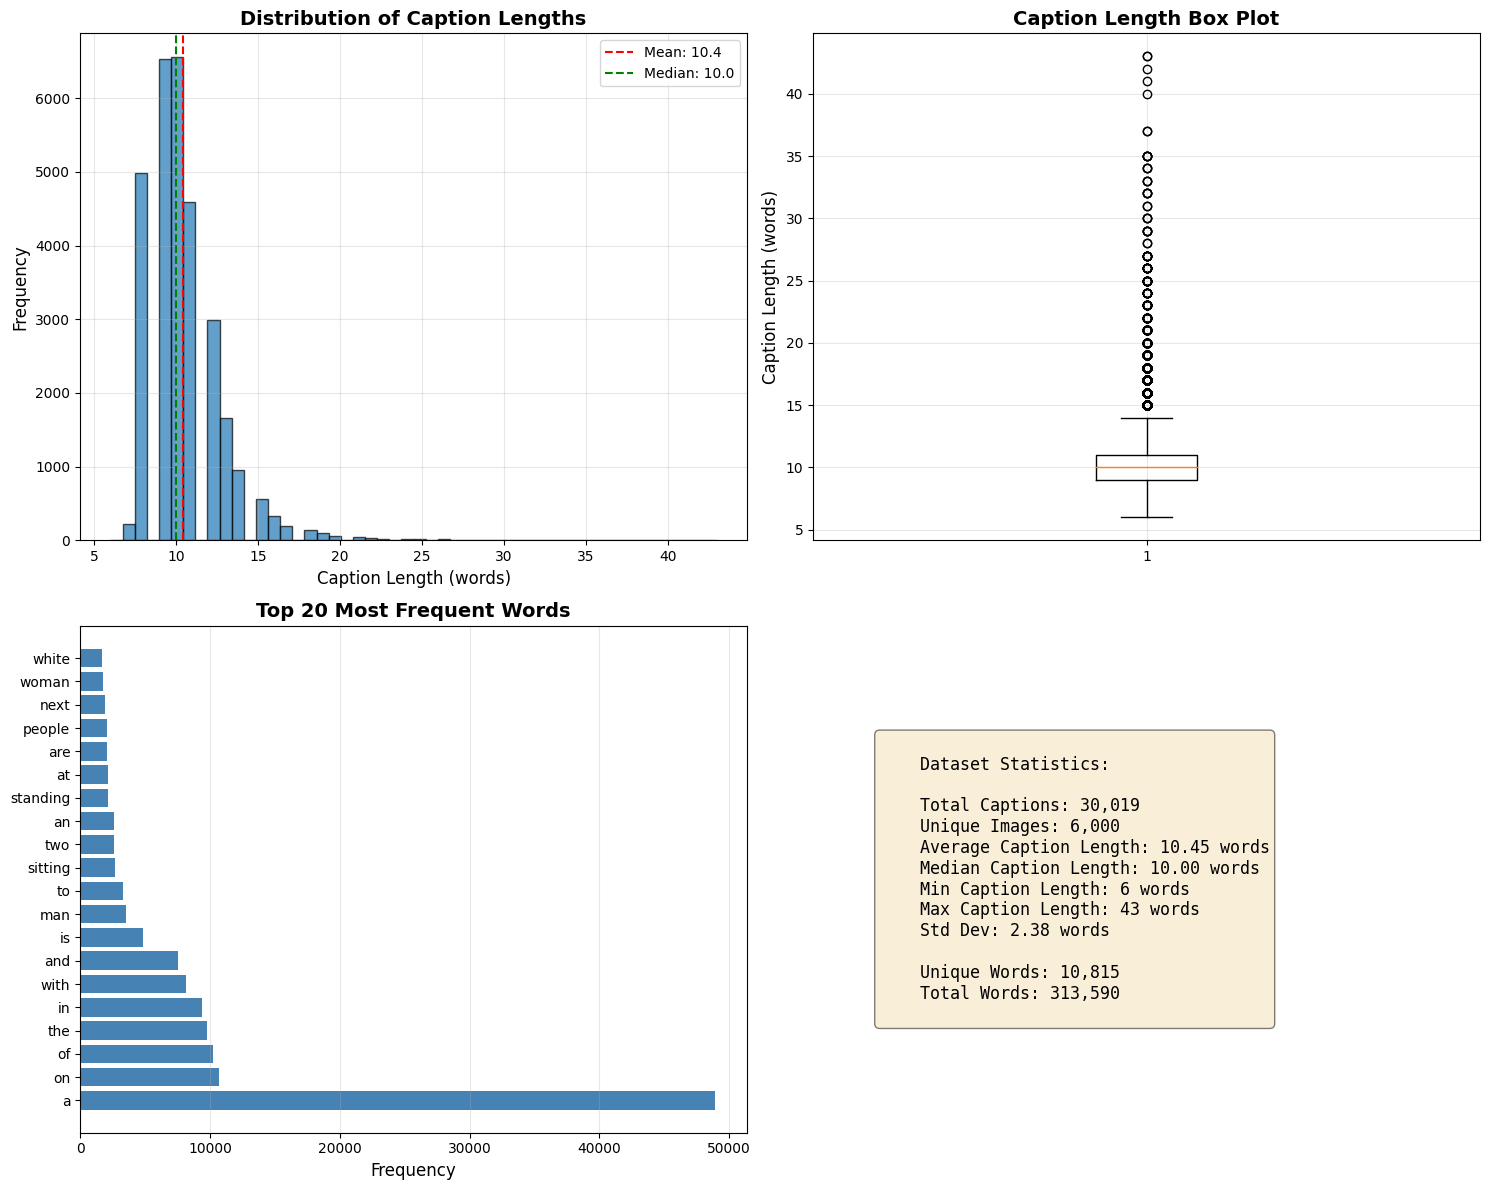

✓ Dataset statistics visualization completed!

Displaying sample images...


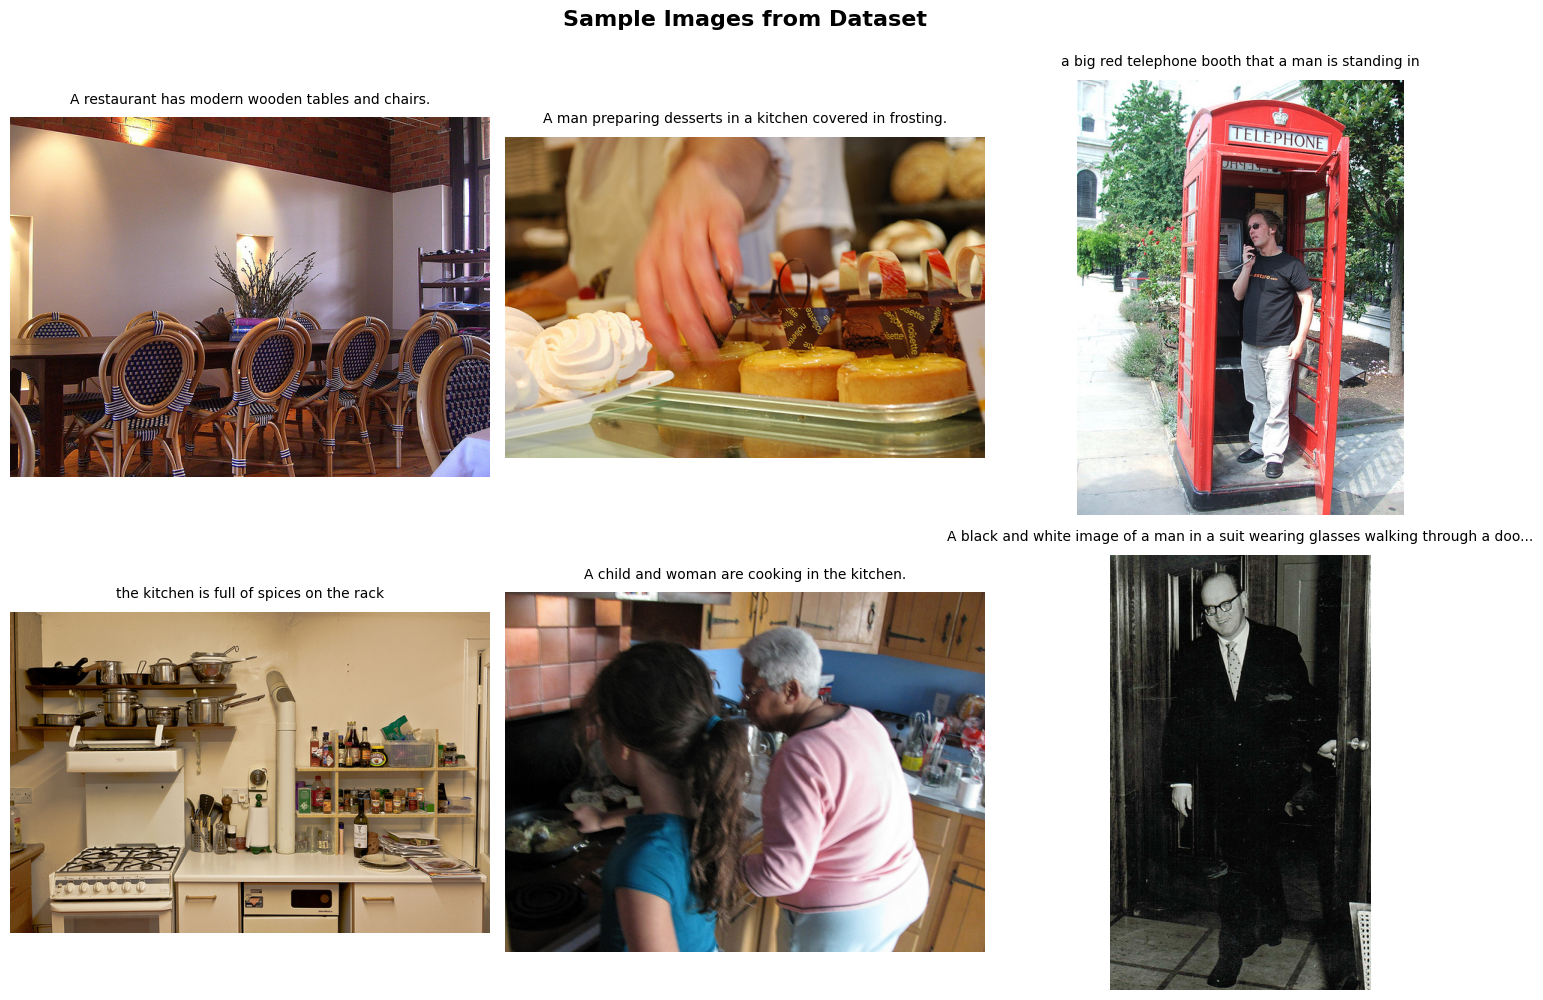

In [13]:
# Visualize dataset statistics
# Note: If you get errors, re-run the cell with 'visualize_dataset_statistics' function definition first
print("Generating dataset visualizations...")
if 'preprocessed_data' in locals() or 'preprocessed_data' in globals():
    dataset_stats = visualize_dataset_statistics(captions_raw=preprocessed_data['captions'])
    print('✓ Dataset statistics visualization completed!')
else:
    print('Warning: preprocessed_data not found. Please run the data preprocessing cells first.')

# Visualize sample images
print("\nDisplaying sample images...")
visualize_sample_images(dataset_hf, num_samples=6)


## Initialize Dataset for Training


## Initialize Model


In [14]:
# Determine prefix size based on CLIP model type
prefix_dim = 640 if CONFIG["is_rn"] else 512

# Determine mapping type
mapping_type = MappingType.MLP if CONFIG["mapping_type"] == "mlp" else MappingType.Transformer

# Initialize model
print("Initializing model...")
if CONFIG["only_prefix"]:
    model = ClipCaptionPrefix(
        prefix_length=CONFIG["prefix_length"],
        clip_length=CONFIG["prefix_length_clip"],
        prefix_size=prefix_dim,
        num_layers=CONFIG["num_layers"],
        mapping_type=mapping_type
    )
    print("Model: ClipCaptionPrefix (frozen GPT-2, train only mapping network)")
else:
    model = ClipCaptionModel(
        prefix_length=CONFIG["prefix_length"],
        clip_length=CONFIG["prefix_length_clip"],
        prefix_size=prefix_dim,
        num_layers=CONFIG["num_layers"],
        mapping_type=mapping_type
    )
    print("Model: ClipCaptionModel (fine-tune GPT-2 and mapping network)")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model mapping type: {CONFIG['mapping_type']}")
print(f"Prefix length: {CONFIG['prefix_length']}")
print(f"Prefix size: {prefix_dim}")

# Move model to device
model = model.to(device)
print(f"Model moved to {device}")


Initializing model...


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model: ClipCaptionModel (fine-tune GPT-2 and mapping network)

Total parameters: 155,908,608
Trainable parameters: 155,908,608
Model mapping type: mlp
Prefix length: 10
Prefix size: 512
Model moved to cuda


In [15]:
# Save preprocessed data to temporary file for ClipCocoDataset
temp_data_path = "./data/coco_temp.pkl"
os.makedirs(os.path.dirname(temp_data_path), exist_ok=True)
with open(temp_data_path, 'wb') as f:
    pickle.dump(preprocessed_data, f)

# Initialize dataset
print("Initializing dataset for training...")
dataset = ClipCocoDataset(
    temp_data_path, 
    prefix_length=CONFIG["prefix_length"],
    normalize_prefix=CONFIG["normalize_prefix"]
)

print(f"\n✓ Dataset initialized successfully!")
print(f"Dataset size: {len(dataset)}")
print(f"Max sequence length: {dataset.max_seq_len}")

# Create validation and test datasets if splits were loaded
if LOAD_ALL_SPLITS:
    print("\n" + "="*60)
    print("Creating validation and test datasets...")
    print("="*60)
    
    # Check if validation data was processed
    val_cache_file = CACHE_FILE.replace('coco_preprocessed', 'coco_val_preprocessed')
    test_cache_file = CACHE_FILE.replace('coco_preprocessed', 'coco_test_preprocessed')
    
    if os.path.exists(val_cache_file):
        print(f"\nInitializing validation dataset from {val_cache_file}...")
        val_temp_path = "./data/coco_val_temp.pkl"
        
        # Load and save val preprocessed data
        with open(val_cache_file, 'rb') as f:
            val_preprocessed_data = pickle.load(f)
        with open(val_temp_path, 'wb') as f:
            pickle.dump(val_preprocessed_data, f)
        
        val_dataset = ClipCocoDataset(
            val_temp_path,
            prefix_length=CONFIG["prefix_length"],
            normalize_prefix=CONFIG["normalize_prefix"]
        )
        print(f"✓ Validation dataset: {len(val_dataset)} samples")
    else:
        print(f"⚠️  Validation data not found at {val_cache_file}")
        print("Run the CLIP feature extraction cell to process validation split")
        val_dataset = None
    
    if os.path.exists(test_cache_file):
        print(f"\nInitializing test dataset from {test_cache_file}...")
        test_temp_path = "./data/coco_test_temp.pkl"
        
        # Load and save test preprocessed data
        with open(test_cache_file, 'rb') as f:
            test_preprocessed_data = pickle.load(f)
        with open(test_temp_path, 'wb') as f:
            pickle.dump(test_preprocessed_data, f)
        
        test_dataset = ClipCocoDataset(
            test_temp_path,
            prefix_length=CONFIG["prefix_length"],
            normalize_prefix=CONFIG["normalize_prefix"]
        )
        print(f"✓ Test dataset: {len(test_dataset)} samples")
    else:
        print(f"⚠️  Test data not found at {test_cache_file}")
        print("Run the CLIP feature extraction cell to process test split")
        test_dataset = None
    
    # Set train_dataset
    train_dataset = dataset
    
    print("\n" + "="*60)
    print("Dataset Splits Summary:")
    print("="*60)
    print(f"  Train: {len(train_dataset) if train_dataset else 0} samples")
    print(f"  Validation: {len(val_dataset) if val_dataset else 0} samples")
    print(f"  Test: {len(test_dataset) if test_dataset else 0} samples")
    print("="*60)
else:
    print("\nSingle dataset mode - no splits")
    train_dataset = dataset
    val_dataset = None
    test_dataset = None


Initializing dataset for training...


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

Saving tokenized data to ./data/coco_temp_tokens.pkl...
Max sequence length: 40

✓ Dataset initialized successfully!
Dataset size: 30019
Max sequence length: 40

Creating validation and test datasets...

Initializing validation dataset from ./data/coco_val_preprocessed.pkl...
Loading data from ./data/coco_val_temp.pkl...
Data size is 1200
Tokenizing captions...


Tokenizing: 100%|██████████| 6002/6002 [00:00<00:00, 6189.63it/s]


Saving tokenized data to ./data/coco_val_temp_tokens.pkl...
Max sequence length: 40
✓ Validation dataset: 6002 samples

Initializing test dataset from ./data/coco_test_preprocessed.pkl...
Loading data from ./data/coco_test_temp.pkl...
Data size is 1200
Tokenizing captions...


Tokenizing: 100%|██████████| 6001/6001 [00:00<00:00, 6206.69it/s]


Saving tokenized data to ./data/coco_test_temp_tokens.pkl...
Max sequence length: 39
✓ Test dataset: 6001 samples

Dataset Splits Summary:
  Train: 30019 samples
  Validation: 6002 samples
  Test: 6001 samples


## Start Training

This will train the model for the specified number of epochs. Checkpoints will be saved automatically.


In [16]:
# Start training

# Use train_dataset if available, otherwise fall back to dataset
if 'train_dataset' in locals() and train_dataset is not None:
    training_data = train_dataset
    print(f"✓ Using train_dataset with {len(training_data)} samples")
else:
    training_data = dataset
    print(f"✓ Using dataset with {len(training_data)} samples (train_dataset not found)")

# Use val_dataset if available
if 'val_dataset' in locals() and val_dataset is not None:
    validation_data = val_dataset
    print(f"✓ Using val_dataset with {len(validation_data)} samples for validation")
else:
    validation_data = None
    print("⚠️  No validation dataset available (val_dataset not found)")

# Initialize MLflow tracking if enabled (optional, won't fail if MLflow has issues)
mlflow_run = None
if USE_MLFLOW and MLFLOW_AVAILABLE:
    try:
        mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)
        mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
        mlflow_run = mlflow.start_run(run_name=f"{OUTPUT_PREFIX}_run")
        
        # Log parameters
        mlflow.log_params(CONFIG)
        mlflow.log_param("dataset_size", len(training_data))
        mlflow.log_param("val_dataset_size", len(validation_data) if validation_data else 0)
        mlflow.log_param("device", str(device))
        print("✓ MLflow tracking started")
    except Exception as e:
        print(f"⚠️  MLflow tracking failed (continuing without it): {e}")
        mlflow_run = None
        USE_MLFLOW = False  # Disable MLflow for this run
else:
    print("ℹ️  MLflow tracking disabled or not available")

trained_model, training_losses, validation_losses = train_model(
    dataset=training_data,
    val_dataset=validation_data,
    model=model,
    epochs=CONFIG["epochs"],
    batch_size=CONFIG["batch_size"],
    lr=CONFIG["learning_rate"],
    warmup_steps=CONFIG["warmup_steps"],
    output_dir=OUTPUT_DIR,
    output_prefix=OUTPUT_PREFIX,
    save_every=CONFIG["save_every"]
)

print("\n" + "="*60)
print("Training completed successfully!")
print("="*60)


✓ Using train_dataset with 30019 samples
✓ Using val_dataset with 6002 samples for validation


2025/12/07 11:33:29 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2025/12/07 11:33:29 INFO mlflow.store.db.utils: Updating database tables
2025/12/07 11:33:29 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2025/12/07 11:33:29 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2025/12/07 11:33:29 INFO alembic.runtime.migration: Running upgrade  -> 451aebb31d03, add metric step
2025/12/07 11:33:29 INFO alembic.runtime.migration: Running upgrade 451aebb31d03 -> 90e64c465722, migrate user column to tags
2025/12/07 11:33:29 INFO alembic.runtime.migration: Running upgrade 90e64c465722 -> 181f10493468, allow nulls for metric values
2025/12/07 11:33:29 INFO alembic.runtime.migration: Running upgrade 181f10493468 -> df50e92ffc5e, Add Experiment Tags Table
2025/12/07 11:33:29 INFO alembic.runtime.migration: Running upgrade df50e92ffc5e -> 7ac759974ad8, Update run tags with larger limit
2025/12/07 11:33:29 INFO alembic.runtime.migration: Running 

⚠️  MLflow tracking failed (continuing without it): Could not find experiment with ID 1

Starting Training
Epochs: 10
Batch Size: 40
Learning Rate: 2e-05
Warmup Steps: 5000
Total Steps: 7500
Validation: Yes
Output Directory: ./checkpoints


>>> Training epoch 1/10


Epoch 1: 100%|██████████| 750/750 [07:22<00:00,  1.69it/s, loss=2.9909, avg_loss=4.0557]


Epoch 1 completed. Average Training Loss: 4.0557
Validation Loss: 3.1202
✓ New best model saved (val_loss: 3.1202)
Checkpoint saved: ./checkpoints/coco_prefix-001.pt

>>> Training epoch 2/10


...

Epoch 8 completed. Average Training Loss: 2.1753
Validation Loss: 2.4208
✓ New best model saved (val_loss: 2.4208)
Checkpoint saved: ./checkpoints/coco_prefix-008.pt

>>> Training epoch 9/10


Epoch 9: 100%|██████████| 750/750 [07:20<00:00,  1.70it/s, loss=2.2740, avg_loss=2.0922]


Epoch 9 completed. Average Training Loss: 2.0922
Validation Loss: 2.4216
Checkpoint saved: ./checkpoints/coco_prefix-009.pt

>>> Training epoch 10/10


Epoch 10: 100%|██████████| 750/750 [07:20<00:00,  1.70it/s, loss=2.1056, avg_loss=2.0262]


Epoch 10 completed. Average Training Loss: 2.0262
Validation Loss: 2.4309
Checkpoint saved: ./checkpoints/coco_prefix-010.pt

Final model saved: ./checkpoints/coco_prefix_final.pt
Training history saved: ./checkpoints/coco_prefix_training_history.json

Training completed successfully!


## Model Evaluation on Test Set


In [17]:
# Evaluate model on test set
print("Evaluating model on test set...")
print("="*60)

# Check if model has been trained
if 'trained_model' not in locals() and 'trained_model' not in globals():
    print("⚠️  Warning: trained_model not found!")
    print("Please run the training cell first, or load a model from checkpoint.")
    print("\nTo load from checkpoint, use:")
    print("  checkpoint_path = './checkpoints/coco_prefix_final.pt'")
    print("  if os.path.exists(checkpoint_path):")
    print("      model.load_state_dict(torch.load(checkpoint_path, map_location=device))")
    print("      trained_model = model")
    print("\nSkipping evaluation...")
else:
    # Load tokenizer
    tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
    
    # Check if test_dataset exists, otherwise use validation split or full dataset
    if 'test_dataset' not in locals() and 'test_dataset' not in globals():
        print("⚠️  Warning: test_dataset not found!")
        print("Using full dataset for evaluation (or create test_dataset from validation split)")
        if 'dataset' in locals() or 'dataset' in globals():
            eval_dataset = dataset
            print(f"Using 'dataset' with {len(eval_dataset)} samples")
        else:
            print("Error: No dataset available for evaluation!")
            eval_dataset = None
    else:
        eval_dataset = test_dataset
    
    if eval_dataset is not None:
        # Evaluate model
        test_metrics, test_references, test_candidates = evaluate_model(
            model=trained_model,
            dataset=eval_dataset,
            tokenizer=tokenizer,
            device=device,
            num_samples=min(100, len(eval_dataset)),
            max_length=77
        )
        
        # Display results
        print("\n" + "="*60)
        print("Test Set Evaluation Results:")
        print("="*60)
        for metric, value in test_metrics.items():
            if isinstance(value, (int, float)):
                print(f"{metric}: {value:.4f}")
            else:
                print(f"{metric}: {value}")
        print("="*60)
        
        # Save evaluation results
        eval_results_path = os.path.join(OUTPUT_DIR, f"{OUTPUT_PREFIX}_test_evaluation.json")
        with open(eval_results_path, 'w') as f:
            json.dump({
                'metrics': test_metrics,
                'num_samples': len(test_references)
            }, f, indent=2)
        print(f"\nEvaluation results saved to: {eval_results_path}")
    else:
        print("Cannot evaluate: No dataset available")


Evaluating model on test set...


Evaluating: 100%|██████████| 100/100 [01:21<00:00,  1.23it/s]


loading annotations into memory...
Done (t=0.00s)
creating index...
Error calculating CIDEr: 'category_id'

Test Set Evaluation Results:
BLEU-1: 0.0826
BLEU-2: 0.0360
BLEU-3: 0.0170
BLEU-4: 0.0096
METEOR: 0.0000
ROUGE-L: 0.1298
CIDEr: 0.0000

Evaluation results saved to: ./checkpoints/coco_prefix_test_evaluation.json


Traceback (most recent call last):
  File "/tmp/ipykernel_47/4277051176.py", line 105, in calculate_cider_score
    coco_gt = COCO(ref_file)
              ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pycocotools/coco.py", line 86, in __init__
    self.createIndex()
  File "/usr/local/lib/python3.11/dist-packages/pycocotools/coco.py", line 108, in createIndex
    catToImgs[ann['category_id']].append(ann['image_id'])
              ~~~^^^^^^^^^^^^^^^
KeyError: 'category_id'


## Comparative Analysis: Multiple Model Variants


In [18]:
# Comparative Analysis: Train and evaluate multiple model variants
print("="*60)
print("COMPARATIVE MODEL ANALYSIS")
print("="*60)

# Check if dataset splits exist, otherwise create them or use full dataset
if 'train_dataset' not in locals() and 'train_dataset' not in globals():
    print("⚠️  Creating train/val/test splits from dataset...")
    if 'dataset' in locals() or 'dataset' in globals():
        # Create train/val/test splits (80/10/10)
        dataset_size = len(dataset)
        train_size = int(0.8 * dataset_size)
        val_size = int(0.1 * dataset_size)
        
        # Create indices
        indices = torch.randperm(dataset_size).tolist()
        train_indices = indices[:train_size]
        val_indices = indices[train_size:train_size + val_size]
        test_indices = indices[train_size + val_size:]
        
        # Note: We can't easily subset ClipCocoDataset, so we'll use the full dataset
        # For proper splits, you would need to create separate dataset instances
        print("Note: Using full dataset for all splits (for proper splits, modify dataset class)")
        print(f"Dataset size: {dataset_size}")
        print("For now, using full dataset for training and evaluation")
        train_dataset = dataset
        val_dataset = dataset  # Using same for simplicity
        test_dataset = dataset  # Using same for simplicity
    else:
        print("Error: 'dataset' not found. Please run dataset initialization cell first.")
        print("Skipping comparative analysis...")
        train_dataset = None
        val_dataset = None
        test_dataset = None

if train_dataset is not None:
    # Model variants to compare
    variants = [
        {'name': 'MLP Mapping', 'mapping_type': 'mlp', 'only_prefix': False},
        {'name': 'Transformer Mapping (Frozen GPT-2)', 'mapping_type': 'transformer', 'only_prefix': True}
    ]
    
    results = {}
    tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
    
    for variant in variants:
        print(f"\n{'='*60}")
        print(f"Training: {variant['name']}")
        print(f"{'='*60}")
        
        # Initialize model variant
        prefix_dim = 640 if CONFIG["is_rn"] else 512
        mapping_type = MappingType.MLP if variant['mapping_type'] == "mlp" else MappingType.Transformer
        
        if variant['only_prefix']:
            model_variant = ClipCaptionPrefix(
                prefix_length=CONFIG["prefix_length"],
                clip_length=CONFIG["prefix_length_clip"],
                prefix_size=prefix_dim,
                num_layers=CONFIG["num_layers"],
                mapping_type=mapping_type
            )
        else:
            model_variant = ClipCaptionModel(
                prefix_length=CONFIG["prefix_length"],
                clip_length=CONFIG["prefix_length_clip"],
                prefix_size=prefix_dim,
                num_layers=CONFIG["num_layers"],
                mapping_type=mapping_type
            )
        
        # Train model (with fewer epochs for comparison)
        model_variant = model_variant.to(device)
        trained_variant, train_losses, val_losses = train_model(
            dataset=train_dataset,
            model=model_variant,
            val_dataset=val_dataset,
            epochs=3,  # Reduced for faster comparison
            batch_size=CONFIG["batch_size"],
            lr=CONFIG["learning_rate"],
            warmup_steps=CONFIG["warmup_steps"],
            output_dir=OUTPUT_DIR,
            output_prefix=f"{OUTPUT_PREFIX}_{variant['mapping_type']}",
            save_every=1,
            validate_every=1
        )
        
        # Evaluate on test set
        print(f"\nEvaluating {variant['name']} on test set...")
        if test_dataset is not None:
            test_metrics, _, _ = evaluate_model(
                model=trained_variant,
                dataset=test_dataset,
                tokenizer=tokenizer,
                device=device,
                num_samples=min(50, len(test_dataset)),
                max_length=77
            )
            
            results[variant['name']] = {
                'train_loss': train_losses[-1] if train_losses else None,
                'val_loss': val_losses[-1] if val_losses else None,
                'test_metrics': test_metrics
            }
            
            print(f"\n{variant['name']} Results:")
            print(f"  Final Train Loss: {train_losses[-1]:.4f}" if train_losses else "  N/A")
            print(f"  Final Val Loss: {val_losses[-1]:.4f}" if val_losses else "  N/A")
            for metric, value in test_metrics.items():
                if isinstance(value, (int, float)):
                    print(f"  {metric}: {value:.4f}")
    
    # Print comparison
    print("\n" + "="*60)
    print("COMPARISON SUMMARY")
    print("="*60)
    for name, result in results.items():
        print(f"\n{name}:")
        if result['test_metrics']:
            for metric, value in result['test_metrics'].items():
                if isinstance(value, (int, float)):
                    print(f"  {metric}: {value:.4f}")
else:
    print("Cannot perform comparative analysis: datasets not available")


COMPARATIVE MODEL ANALYSIS

Training: MLP Mapping

Starting Training
Epochs: 3
Batch Size: 40
Learning Rate: 2e-05
Warmup Steps: 5000
Total Steps: 2250
Validation: Yes
Output Directory: ./checkpoints


>>> Training epoch 1/3


Epoch 1: 100%|██████████| 750/750 [07:20<00:00,  1.70it/s, loss=3.0774, avg_loss=4.0874]


Epoch 1 completed. Average Training Loss: 4.0874
Validation Loss: 3.0945
✓ New best model saved (val_loss: 3.0945)
Checkpoint saved: ./checkpoints/coco_prefix_mlp-001.pt

>>> Training epoch 2/3


Epoch 2: 100%|██████████| 750/750 [07:20<00:00,  1.70it/s, loss=2.9365, avg_loss=3.0100]


Epoch 2 completed. Average Training Loss: 3.0100
Validation Loss: 2.7408
✓ New best model saved (val_loss: 2.7408)
Checkpoint saved: ./checkpoints/coco_prefix_mlp-002.pt

>>> Training epoch 3/3


...

Epoch 3: 100%|██████████| 750/750 [07:42<00:00,  1.62it/s, loss=2.6449, avg_loss=2.8351]


Epoch 3 completed. Average Training Loss: 2.8351
Validation Loss: 2.8172
✓ New best model saved (val_loss: 2.8172)
Checkpoint saved: ./checkpoints/coco_prefix_transformer-003.pt

Final model saved: ./checkpoints/coco_prefix_transformer_final.pt
Training history saved: ./checkpoints/coco_prefix_transformer_training_history.json

Evaluating Transformer Mapping (Frozen GPT-2) on test set...


Evaluating: 100%|██████████| 50/50 [00:37<00:00,  1.32it/s]

loading annotations into memory...
Done (t=0.00s)
creating index...
Error calculating CIDEr: 'category_id'

Transformer Mapping (Frozen GPT-2) Results:
  Final Train Loss: 2.8351
  Final Val Loss: 2.8172
  BLEU-1: 0.0729
  BLEU-2: 0.0232
  BLEU-3: 0.0120
  BLEU-4: 0.0078
  METEOR: 0.0000
  ROUGE-L: 0.1035
  CIDEr: 0.0000

COMPARISON SUMMARY

MLP Mapping:
  BLEU-1: 0.0765
  BLEU-2: 0.0352
  BLEU-3: 0.0182
  BLEU-4: 0.0102
  METEOR: 0.0000
  ROUGE-L: 0.1223
  CIDEr: 0.0000

Transformer Mapping (Frozen GPT-2):
  BLEU-1: 0.0729
  BLEU-2: 0.0232
  BLEU-3: 0.0120
  BLEU-4: 0.0078
  METEOR: 0.0000
  ROUGE-L: 0.1035
  CIDEr: 0.0000



Traceback (most recent call last):
  File "/tmp/ipykernel_47/4277051176.py", line 105, in calculate_cider_score
    coco_gt = COCO(ref_file)
              ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pycocotools/coco.py", line 86, in __init__
    self.createIndex()
  File "/usr/local/lib/python3.11/dist-packages/pycocotools/coco.py", line 108, in createIndex
    catToImgs[ann['category_id']].append(ann['image_id'])
              ~~~^^^^^^^^^^^^^^^
KeyError: 'category_id'


## Training Loss Visualization


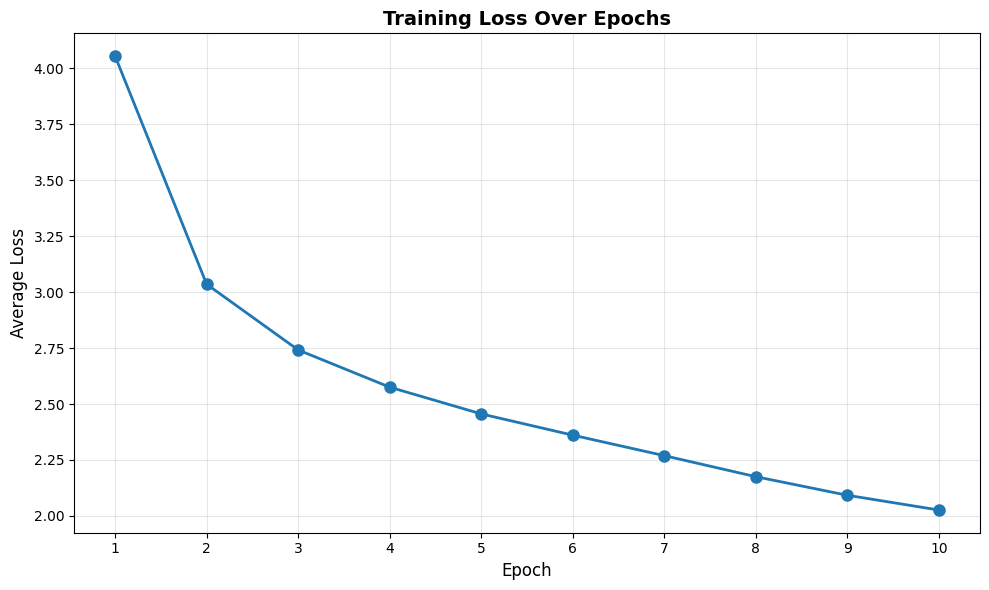

Final training loss: 2.0262
Best training loss: 2.0262 (Epoch 10)


In [19]:
# Plot training loss
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(training_losses) + 1), training_losses, marker='o', linewidth=2, markersize=8)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Average Loss', fontsize=12)
plt.title('Training Loss Over Epochs', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(range(1, len(training_losses) + 1))
plt.tight_layout()
plt.show()

print(f"Final training loss: {training_losses[-1]:.4f}")
print(f"Best training loss: {min(training_losses):.4f} (Epoch {training_losses.index(min(training_losses)) + 1})")


## Save Model for Download

The model checkpoints are saved in the `checkpoints` directory. In Kaggle, you can download them from the Output tab.


In [20]:
# List all saved checkpoints
print("Saved checkpoints:")
print("="*60)
if os.path.exists(OUTPUT_DIR):
    checkpoints = [f for f in os.listdir(OUTPUT_DIR) if f.endswith('.pt')]
    for checkpoint in sorted(checkpoints):
        checkpoint_path = os.path.join(OUTPUT_DIR, checkpoint)
        size_mb = os.path.getsize(checkpoint_path) / (1024 * 1024)
        print(f"  {checkpoint} ({size_mb:.2f} MB)")
    print(f"\nTotal checkpoints: {len(checkpoints)}")
    print(f"\nTo download: Go to Output tab → Download all outputs")
else:
    print("No checkpoints directory found.")


Saved checkpoints:
  coco_prefix-001.pt (594.80 MB)
  coco_prefix-002.pt (594.80 MB)
  coco_prefix-003.pt (594.80 MB)
  coco_prefix-004.pt (594.80 MB)
  coco_prefix-005.pt (594.80 MB)
  coco_prefix-006.pt (594.80 MB)
  coco_prefix-007.pt (594.80 MB)
  coco_prefix-008.pt (594.80 MB)
  coco_prefix-009.pt (594.80 MB)
  coco_prefix-010.pt (594.80 MB)
  coco_prefix_best.pt (594.80 MB)
  coco_prefix_final.pt (594.80 MB)
  coco_prefix_mlp-001.pt (594.80 MB)
  coco_prefix_mlp-002.pt (594.80 MB)
  coco_prefix_mlp-003.pt (594.80 MB)
  coco_prefix_mlp_best.pt (594.80 MB)
  coco_prefix_mlp_final.pt (594.80 MB)
  coco_prefix_transformer-001.pt (634.04 MB)
  coco_prefix_transformer-002.pt (634.04 MB)
  coco_prefix_transformer-003.pt (634.04 MB)
  coco_prefix_transformer_best.pt (634.04 MB)
  coco_prefix_transformer_final.pt (634.04 MB)

Total checkpoints: 22

To download: Go to Output tab → Download all outputs


In [21]:
# ========== DOWNLOAD CHECKPOINT FILE DIRECTLY TO LAPTOP ==========
# This cell helps you download the checkpoint file directly to your laptop
# Run this cell after training to download the checkpoint

import os
import shutil
from pathlib import Path

print("="*60)
print("Download Checkpoint File to Laptop")
print("="*60)

# Source path in Kaggle working directory
kaggle_checkpoint_dir = "/kaggle/working/checkpoints"
checkpoint_filename = "coco_prefix_final.pt"
source_path = os.path.join(kaggle_checkpoint_dir, checkpoint_filename)

# Check if checkpoint exists
if os.path.exists(source_path):
    file_size_mb = os.path.getsize(source_path) / (1024 * 1024)
    print(f"✓ Found checkpoint: {source_path}")
    print(f"  File size: {file_size_mb:.2f} MB")
    
    # Copy to current directory (will be available in Kaggle output)
    output_path = f"./{checkpoint_filename}"
    
    try:
        shutil.copy2(source_path, output_path)
        print(f"✓ Checkpoint copied to: {output_path}")
        
        # ========== OPTION 1: Manual Download from Kaggle (EASIEST) ==========
        print(f"\n{'='*60}")
        print("OPTION 1: Download from Kaggle Output Tab (EASIEST - No Code Needed!)")
        print(f"{'='*60}")
        print("This is the simplest method:")
        print("1. Go to your Kaggle notebook page")
        print("2. Click on the 'Output' tab (next to 'Code' and 'Data')")
        print(f"3. Find '{checkpoint_filename}' in the file list")
        print("4. Click the download icon (⬇️) next to the file")
        print("5. The file downloads directly to your laptop's Downloads folder!")
        print("\nNote: All files in /kaggle/working are automatically saved to Output tab")
        
        # ========== OPTION 1B: Google Drive (Alternative) ==========
        print(f"\n{'='*60}")
        print("OPTION 1B: Upload to Google Drive (If you prefer cloud storage)")
        print(f"{'='*60}")
        print("If you want to use Google Drive, the easiest way is:")
        print("1. First download from Kaggle Output tab (Option 1 above)")
        print("2. Then manually upload to Google Drive from your laptop")
        print("\nOR use this simple method in a new cell:")
        print("\n# Simple method using requests (requires manual token)")
        print("!pip install -q requests")
        print("# Note: You'll need to get an access token from Google Drive API")
        print("# For most users, downloading from Kaggle Output tab is easier")
        
        # ========== OPTION 2: Auto-Download Script ==========
        print(f"\n{'='*60}")
        print("OPTION 2: Auto-Download Script (Run on Your Laptop)")
        print(f"{'='*60}")
        
        # Create a Python script that can be downloaded and run on laptop
        download_script = f'''#!/usr/bin/env python3
"""
Auto-download checkpoint from Kaggle
Run this script on your laptop to automatically download the checkpoint file.
"""

import os
import subprocess
import sys
from pathlib import Path

def check_kaggle_installed():
    """Check if Kaggle API is installed"""
    try:
        import kaggle
        return True
    except ImportError:
        return False

def setup_kaggle():
    """Install and setup Kaggle API"""
    print("Installing Kaggle API...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "kaggle", "--quiet"])
    print("✓ Kaggle API installed")
    
    # Check for credentials
    kaggle_dir = Path.home() / ".kaggle"
    kaggle_json = kaggle_dir / "kaggle.json"
    
    if not kaggle_json.exists():
        print("\\n⚠️  Kaggle credentials not found!")
        print("Please setup Kaggle API credentials:")
        print("1. Go to: https://www.kaggle.com/settings")
        print("2. Click 'Create New Token'")
        print("3. Download kaggle.json")
        print(f"4. Save it to: {kaggle_json}")
        print("   On Windows: C:\\\\Users\\\\YourUsername\\\\.kaggle\\\\kaggle.json")
        print("   On Mac/Linux: ~/.kaggle/kaggle.json")
        return False
    
    # Set permissions (important on Linux/Mac)
    if os.name != 'nt':  # Not Windows
        os.chmod(kaggle_json, 0o600)
        os.chmod(kaggle_dir, 0o700)
    
    return True

def download_checkpoint(username, notebook_name, checkpoint_name="{checkpoint_filename}", output_dir="./checkpoints"):
    """Download checkpoint from Kaggle"""
    try:
        from kaggle.api.kaggle_api_extended import KaggleApi
        api = KaggleApi()
        api.authenticate()
        
        print(f"\\nDownloading checkpoint from {username}/{notebook_name}...")
        print(f"Checkpoint file: {checkpoint_name}")
        print(f"Output directory: {output_dir}")
        
        # Create output directory
        os.makedirs(output_dir, exist_ok=True)
        
        # Download the file
        api.kernels_output(
            kernel=f"{{username}}/{{notebook_name}}",
            path=output_dir,
            force=True
        )
        
        # Check if file was downloaded
        checkpoint_path = os.path.join(output_dir, checkpoint_name)
        if os.path.exists(checkpoint_path):
            file_size = os.path.getsize(checkpoint_path) / (1024 * 1024)
            print(f"\\n✓ Successfully downloaded!")
            print(f"  File: {checkpoint_path}")
            print(f"  Size: {{file_size:.2f}} MB")
            return True
        else:
            # File might be in output_dir root
            possible_paths = [
                os.path.join(output_dir, checkpoint_name),
                checkpoint_name,
                os.path.join(".", checkpoint_name)
            ]
            for path in possible_paths:
                if os.path.exists(path):
                    print(f"\\n✓ Found checkpoint at: {path}")
                    return True
            
            print("\\n⚠️  Checkpoint downloaded but not found at expected location")
            print(f"   Check the {output_dir} directory")
            return False
            
    except Exception as e:
        print(f"\\n❌ Error downloading: {{e}}")
        print("\\nTroubleshooting:")
        print("1. Make sure your Kaggle credentials are set up correctly")
        print("2. Verify the username and notebook name are correct")
        print("3. Make sure the notebook has been run and has outputs")
        return False

def main():
    print("="*60)
    print("Kaggle Checkpoint Auto-Downloader")
    print("="*60)
    
    # Get username and notebook name
    print("\\nPlease provide your Kaggle notebook details:")
    username = input("Kaggle username: ").strip()
    notebook_name = input("Notebook name (slug): ").strip()
    
    if not username or not notebook_name:
        print("\\n❌ Username and notebook name are required!")
        return
    
    # Check/install Kaggle
    if not check_kaggle_installed():
        if not setup_kaggle():
            return
    
    # Download checkpoint
    success = download_checkpoint(username, notebook_name)
    
    if success:
        print("\\n" + "="*60)
        print("✓ Download complete!")
        print("="*60)
    else:
        print("\\n" + "="*60)
        print("❌ Download failed. Please check the error messages above.")
        print("="*60)

if __name__ == "__main__":
    main()
'''
        
        # Save the script to a file
        script_filename = "download_checkpoint.py"
        with open(script_filename, 'w') as f:
            f.write(download_script)
        
        print(f"✓ Created auto-download script: {script_filename}")
        print(f"\n📥 To use this script:")
        print(f"   1. Download '{script_filename}' from Kaggle Output tab")
        print(f"   2. On your laptop, open terminal/command prompt")
        print(f"   3. Navigate to the folder where you saved the script")
        print(f"   4. Run: python {script_filename}")
        print(f"   5. Enter your Kaggle username and notebook name when prompted")
        print(f"   6. The checkpoint will download automatically!")
        print(f"\n   The script will:")
        print(f"   - Install Kaggle API if needed")
        print(f"   - Guide you through credential setup")
        print(f"   - Download the checkpoint automatically")
        
        # Also create a simpler batch/shell script version
        batch_script_windows = f'''@echo off
echo ============================================================
echo Kaggle Checkpoint Downloader (Windows)
echo ============================================================
echo.
echo This script will download your checkpoint using Kaggle API
echo.
pause

REM Install Kaggle API
pip install kaggle --quiet

REM Get user input
set /p USERNAME="Enter your Kaggle username: "
set /p NOTEBOOK="Enter your notebook name (slug): "

REM Download checkpoint
kaggle kernels output %USERNAME%/%NOTEBOOK% -p ./checkpoints -f {checkpoint_filename}

echo.
echo ============================================================
echo Download complete! Check the ./checkpoints folder
echo ============================================================
pause
'''
        
        shell_script_unix = f'''#!/bin/bash
echo "============================================================"
echo "Kaggle Checkpoint Downloader (Mac/Linux)"
echo "============================================================"
echo ""
echo "This script will download your checkpoint using Kaggle API"
echo ""
read -p "Press Enter to continue..."

# Install Kaggle API
pip install kaggle --quiet

# Get user input
read -p "Enter your Kaggle username: " USERNAME
read -p "Enter your notebook name (slug): " NOTEBOOK

# Download checkpoint
kaggle kernels output "$USERNAME/$NOTEBOOK" -p ./checkpoints -f {checkpoint_filename}

echo ""
echo "============================================================"
echo "Download complete! Check the ./checkpoints folder"
echo "============================================================"
'''
        
        with open("download_checkpoint.bat", 'w') as f:
            f.write(batch_script_windows)
        
        with open("download_checkpoint.sh", 'w') as f:
            f.write(shell_script_unix)
        
        # Make shell script executable
        os.chmod("download_checkpoint.sh", 0o755)
        
        print(f"\n✓ Also created:")
        print(f"   - download_checkpoint.bat (for Windows)")
        print(f"   - download_checkpoint.sh (for Mac/Linux)")
        print(f"\n   These are simpler scripts that use Kaggle CLI directly")
        
        # ========== OPTION 3: Manual Download ==========
        print(f"\n{'='*60}")
        print("OPTION 3: Manual Download from Kaggle Website")
        print(f"{'='*60}")
        print("1. Go to your Kaggle notebook")
        print("2. Click on the 'Output' tab")
        print(f"3. Find '{checkpoint_filename}' in the file list")
        print("4. Click the download icon (⬇️) next to the file")
        print("5. The file will download directly to your laptop")
        
        # ========== OPTION 4: Direct Download Script ==========
        print(f"\n{'='*60}")
        print("OPTION 4: Create Download Script")
        print(f"{'='*60}")
        print("The checkpoint is now available in Kaggle's Output tab.")
        print("All files in /kaggle/working are automatically saved to Output.")
        print(f"\nFile location: {source_path}")
        print(f"Also copied to: {output_path}")
        
    except Exception as e:
        print(f"⚠️  Error copying file: {e}")
        print(f"   The checkpoint is still available at: {source_path}")
        print(f"   Files in /kaggle/working are automatically saved to Output tab")
else:
    print(f"⚠️  Checkpoint not found at: {source_path}")
    print(f"\n   Checking for other checkpoint files...")
    
    # List all checkpoint files
    if os.path.exists(kaggle_checkpoint_dir):
        checkpoints = [f for f in os.listdir(kaggle_checkpoint_dir) if f.endswith('.pt')]
        if checkpoints:
            print(f"\n   Found {len(checkpoints)} checkpoint file(s):")
            for ckpt in sorted(checkpoints):
                ckpt_path = os.path.join(kaggle_checkpoint_dir, ckpt)
                size_mb = os.path.getsize(ckpt_path) / (1024 * 1024)
                print(f"     - {ckpt} ({size_mb:.2f} MB)")
            
            # Copy the first one found
            first_ckpt = sorted(checkpoints)[0]
            first_ckpt_path = os.path.join(kaggle_checkpoint_dir, first_ckpt)
            try:
                shutil.copy2(first_ckpt_path, f"./{first_ckpt}")
                print(f"\n✓ Copied {first_ckpt} to current directory")
            except:
                pass
            
            print(f"\n   To download any checkpoint:")
            print(f"     1. Go to Kaggle notebook → Output tab")
            print(f"     2. All files in /kaggle/working/checkpoints are automatically saved")
            print(f"     3. Click download icon next to the file you want")
        else:
            print(f"   No .pt files found in {kaggle_checkpoint_dir}")
            print(f"   Make sure training has completed and checkpoint was saved")
    else:
        print(f"   Directory {kaggle_checkpoint_dir} does not exist")
        print(f"   Make sure training has been run")

print(f"\n{'='*60}")
print("⭐ RECOMMENDED: Use Kaggle Output Tab (No Code Needed!)")
print(f"{'='*60}")
print("This is the EASIEST and FASTEST method:")
print("")
print("1. After running this cell, scroll up to your Kaggle notebook")
print("2. Click on the 'Output' tab (at the top, next to 'Code' and 'Data')")
print("3. You'll see all files from /kaggle/working/checkpoints/")
print(f"4. Find '{checkpoint_filename}' in the list")
print("5. Click the download icon (⬇️) next to the file")
print("6. File downloads directly to your laptop's Downloads folder!")
print("")
print("✅ No code, no setup, no errors - just click and download!")
print("="*60)



Download Checkpoint File to Laptop
✓ Found checkpoint: /kaggle/working/checkpoints/coco_prefix_final.pt
  File size: 594.80 MB
✓ Checkpoint copied to: ./coco_prefix_final.pt

OPTION 1: Download from Kaggle Output Tab (EASIEST - No Code Needed!)
This is the simplest method:
1. Go to your Kaggle notebook page
2. Click on the 'Output' tab (next to 'Code' and 'Data')
3. Find 'coco_prefix_final.pt' in the file list
4. Click the download icon (⬇️) next to the file
5. The file downloads directly to your laptop's Downloads folder!

Note: All files in /kaggle/working are automatically saved to Output tab

OPTION 1B: Upload to Google Drive (If you prefer cloud storage)
If you want to use Google Drive, the easiest way is:
1. First download from Kaggle Output tab (Option 1 above)
2. Then manually upload to Google Drive from your laptop

OR use this simple method in a new cell:

# Simple method using requests (requires manual token)
!pip install -q requests
# Note: You'll need to get an access toke

In [26]:
# ========== ABLATION STUDY: HYPERPARAMETER ANALYSIS ==========

import pandas as pd
from collections import defaultdict
from tqdm import tqdm
import sys
from io import StringIO

# Wrapper function to train with compact one-line-per-epoch output
def train_model_compact(dataset, model, **kwargs):
    """Train model with compact output showing progress, one line per epoch summary"""
    import sys
    from io import StringIO
    
    # Capture print statements to intercept epoch summaries
    captured_output = StringIO()
    original_stdout = sys.stdout
    
    # Track if we're in an epoch print statement
    epoch_summaries = []
    
    class EpochCapture:
        def __init__(self, original):
            self.original = original
            self.buffer = []
        
        def write(self, text):
            # Intercept epoch completion messages (train_model prints: "Epoch X completed. Average Training Loss: Y")
            import re
            if "Epoch" in text and "completed" in text:
                # Match: "Epoch X completed. Average Training Loss: Y.XXXX"
                match = re.search(r'Epoch (\d+).*?Average Training Loss: ([\d.]+)', text)
                if match:
                    epoch_num = match.group(1)
                    loss = match.group(2)
                    # Print compact format on same line, overwriting progress
                    self.original.write(f"E{epoch_num}: {loss} | ")
                    self.original.flush()
                    return  # Don't write the original message
            
            # Pass through all other output (including tqdm progress bars)
            self.original.write(text)
        
        def flush(self):
            self.original.flush()
    
    # Replace stdout temporarily
    epoch_capture = EpochCapture(original_stdout)
    sys.stdout = epoch_capture
    
    try:
        # Train normally - tqdm will show progress, epoch summaries will be intercepted
        trained_model, train_losses, val_losses = train_model(
            dataset=dataset,
            model=model,
            **kwargs
        )
        
        # Print final compact summary on one line (overwrite any trailing content)
        if train_losses:
            epoch_str = " | ".join([f"E{i+1}: {loss:.4f}" for i, loss in enumerate(train_losses)])
            original_stdout.write(f"\r{epoch_str} " + " " * 50 + "\n")  # Clear line and print summary
        else:
            original_stdout.write("\n")
        
    finally:
        # Restore stdout
        sys.stdout = original_stdout
    
    return trained_model, train_losses, val_losses

print("="*70)
print("ABLATION STUDY: HYPERPARAMETER ANALYSIS")
print("="*70)
print("This study tests different hyperparameters to understand their impact.")
print("Each configuration will be trained for 2-3 epochs for efficiency.\n")

# Ablation study configuration
ABLATION_EPOCHS = 3  # Reduced epochs for faster ablation study

# Check if dataset exists
if 'dataset' not in locals() and 'dataset' not in globals():
    print("⚠️  Error: 'dataset' not found. Please run dataset initialization cells first.")
    print("Skipping ablation study...")
else:
    # Use existing dataset or create a small subset for faster ablation
    ablation_dataset = dataset
    
    # Store results
    ablation_results = []
    
    # Load tokenizer once
    tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
    
    # ========== TEST 1: Prefix Length ==========
    print("\n" + "="*70)
    print("TEST 1: Varying Prefix Length")
    print("="*70)
    
    prefix_lengths = [5, 10]  # Testing 2 values
    base_lr = 2e-5
    base_batch_size = 40
    
    for prefix_len in prefix_lengths:
        
        try:
            # Create a new dataset instance with matching prefix_length
            # Use the same temp data file but with different prefix_length
            temp_data_path = "./data/coco_temp.pkl"
            if not os.path.exists(temp_data_path):
                raise FileNotFoundError(f"Required file not found: {temp_data_path}. Please run dataset initialization cells first.")
            
            # Always create a fresh dataset instance with the correct prefix_length
            # This ensures tokens are padded correctly for the current prefix_length
            ablation_dataset_prefix = ClipCocoDataset(
                temp_data_path,
                prefix_length=prefix_len,
                normalize_prefix=CONFIG.get("normalize_prefix", False)
            )
            
            # Verify dataset prefix_length matches model prefix_length
            if ablation_dataset_prefix.prefix_length != prefix_len:
                raise ValueError(f"Dataset prefix_length ({ablation_dataset_prefix.prefix_length}) must match model prefix_length ({prefix_len})")
            
            # Initialize model with current prefix length
            prefix_dim = 512  # ViT-B/32 embedding size
            model_ablation = ClipCaptionModel(
                prefix_length=prefix_len,
                prefix_size=prefix_dim,
                mapping_type=MappingType.MLP
            )
            model_ablation = model_ablation.to(device)
            
            # Train for reduced epochs with compact output
            print(f"Prefix Length {prefix_len}: Training...", end=" ")
            trained_model_ablation, train_losses, val_losses = train_model_compact(
                dataset=ablation_dataset_prefix,
                model=model_ablation,
                val_dataset=None,  # Skip validation for speed
                epochs=ABLATION_EPOCHS,
                batch_size=base_batch_size,
                lr=base_lr,
                warmup_steps=500,
                output_dir=OUTPUT_DIR,
                output_prefix=f"ablation_prefix_{prefix_len}",
                save_every=ABLATION_EPOCHS,
                validate_every=0
            )
            
            # Quick evaluation on small subset
            print(f"| Evaluating...", end=" ")
            eval_metrics, _, _ = evaluate_model(
                model=trained_model_ablation,
                dataset=ablation_dataset_prefix,
                tokenizer=tokenizer,
                device=device,
                num_samples=min(50, len(ablation_dataset_prefix)),
                max_length=77
            )
            
            # Store results
            result = {
                'Hyperparameter': 'Prefix Length',
                'Value': prefix_len,
                'BLEU-4': eval_metrics.get('BLEU-4', 0),
                'METEOR': eval_metrics.get('METEOR', 0),
                'CIDEr': eval_metrics.get('CIDEr', 0),
                'Final Train Loss': train_losses[-1] if train_losses else None
            }
            ablation_results.append(result)
            
            print(f"| BLEU-4={eval_metrics.get('BLEU-4', 0):.4f}, "
                  f"METEOR={eval_metrics.get('METEOR', 0):.4f}, "
                  f"CIDEr={eval_metrics.get('CIDEr', 0):.4f}")
            
            # Clean up model to save memory
            del model_ablation, trained_model_ablation
            torch.cuda.empty_cache()
            
        except Exception as e:
            print(f"✗ Error testing prefix length {prefix_len}: {e}")
            continue
    
    # ========== TEST 2: Learning Rate ==========
    print("\n\n" + "="*70)
    print("TEST 2: Varying Learning Rate")
    print("="*70)
    
    learning_rates = [1e-5, 2e-5]  # Testing 2 values
    base_prefix_length = 10
    
    for lr in learning_rates:
        
        try:
            # Initialize model
            prefix_dim = 512
            model_ablation = ClipCaptionModel(
                prefix_length=base_prefix_length,
                prefix_size=prefix_dim,
                mapping_type=MappingType.MLP
            )
            model_ablation = model_ablation.to(device)
            
            # Train with compact output
            print(f"Learning Rate {lr:.0e}: Training...", end=" ")
            trained_model_ablation, train_losses, val_losses = train_model_compact(
                dataset=ablation_dataset,
                model=model_ablation,
                val_dataset=None,
                epochs=ABLATION_EPOCHS,
                batch_size=base_batch_size,
                lr=lr,
                warmup_steps=500,
                output_dir=OUTPUT_DIR,
                output_prefix=f"ablation_lr_{lr:.0e}",
                save_every=ABLATION_EPOCHS,
                validate_every=0
            )
            
            # Evaluate
            print(f"| Evaluating...", end=" ")
            eval_metrics, _, _ = evaluate_model(
                model=trained_model_ablation,
                dataset=ablation_dataset,
                tokenizer=tokenizer,
                device=device,
                num_samples=min(50, len(ablation_dataset)),
                max_length=77
            )
            
            # Store results
            result = {
                'Hyperparameter': 'Learning Rate',
                'Value': f'{lr:.0e}',
                'BLEU-4': eval_metrics.get('BLEU-4', 0),
                'METEOR': eval_metrics.get('METEOR', 0),
                'CIDEr': eval_metrics.get('CIDEr', 0),
                'Final Train Loss': train_losses[-1] if train_losses else None
            }
            ablation_results.append(result)
            
            print(f"| BLEU-4={eval_metrics.get('BLEU-4', 0):.4f}, "
                  f"METEOR={eval_metrics.get('METEOR', 0):.4f}, "
                  f"CIDEr={eval_metrics.get('CIDEr', 0):.4f}")
            
            del model_ablation, trained_model_ablation
            torch.cuda.empty_cache()
            
        except Exception as e:
            print(f"✗ Error testing learning rate {lr:.0e}: {e}")
            continue
    
    # ========== TEST 3: Batch Size ==========
    print("\n\n" + "="*70)
    print("TEST 3: Varying Batch Size")
    print("="*70)
    
    batch_sizes = [32, 40]  # Testing 2 values
    
    for batch_size in batch_sizes:
        
        try:
            # Initialize model
            prefix_dim = 512
            model_ablation = ClipCaptionModel(
                prefix_length=base_prefix_length,
                prefix_size=prefix_dim,
                mapping_type=MappingType.MLP
            )
            model_ablation = model_ablation.to(device)
            
            # Train with compact output
            print(f"Batch Size {batch_size}: Training...", end=" ")
            trained_model_ablation, train_losses, val_losses = train_model_compact(
                dataset=ablation_dataset,
                model=model_ablation,
                val_dataset=None,
                epochs=ABLATION_EPOCHS,
                batch_size=batch_size,
                lr=base_lr,
                warmup_steps=500,
                output_dir=OUTPUT_DIR,
                output_prefix=f"ablation_batch_{batch_size}",
                save_every=ABLATION_EPOCHS,
                validate_every=0
            )
            
            # Evaluate
            print(f"| Evaluating...", end=" ")
            eval_metrics, _, _ = evaluate_model(
                model=trained_model_ablation,
                dataset=ablation_dataset,
                tokenizer=tokenizer,
                device=device,
                num_samples=min(50, len(ablation_dataset)),
                max_length=77
            )
            
            # Store results
            result = {
                'Hyperparameter': 'Batch Size',
                'Value': batch_size,
                'BLEU-4': eval_metrics.get('BLEU-4', 0),
                'METEOR': eval_metrics.get('METEOR', 0),
                'CIDEr': eval_metrics.get('CIDEr', 0),
                'Final Train Loss': train_losses[-1] if train_losses else None
            }
            ablation_results.append(result)
            
            print(f"| BLEU-4={eval_metrics.get('BLEU-4', 0):.4f}, "
                  f"METEOR={eval_metrics.get('METEOR', 0):.4f}, "
                  f"CIDEr={eval_metrics.get('CIDEr', 0):.4f}")
            
            del model_ablation, trained_model_ablation
            torch.cuda.empty_cache()
            
        except Exception as e:
            print(f"✗ Error testing batch size {batch_size}: {e}")
            continue
    
    # ========== RESULTS SUMMARY ==========
    print("\n\n" + "="*70)
    print("ABLATION STUDY RESULTS SUMMARY")
    print("="*70)
    
    if ablation_results:
        # Create DataFrame for better visualization
        df_results = pd.DataFrame(ablation_results)
        
        # Display results by hyperparameter
        for hyperparam in df_results['Hyperparameter'].unique():
            print(f"\n{hyperparam}:")
            print("-" * 70)
            subset = df_results[df_results['Hyperparameter'] == hyperparam]
            for _, row in subset.iterrows():
                print(f"  Value: {row['Value']}")
                print(f"    BLEU-4: {row['BLEU-4']:.4f}")
                print(f"    METEOR: {row['METEOR']:.4f}")
                print(f"    CIDEr: {row['CIDEr']:.4f}")
                if row['Final Train Loss'] is not None:
                    print(f"    Final Train Loss: {row['Final Train Loss']:.4f}")
                print()
        
        # Find best configurations
        print("\n" + "="*70)
        print("BEST CONFIGURATIONS")
        print("="*70)
        
        best_bleu = df_results.loc[df_results['BLEU-4'].idxmax()]
        best_meteor = df_results.loc[df_results['METEOR'].idxmax()]
        best_cider = df_results.loc[df_results['CIDEr'].idxmax()]
        
        print(f"\nBest BLEU-4: {best_bleu['Hyperparameter']} = {best_bleu['Value']} "
              f"(BLEU-4: {best_bleu['BLEU-4']:.4f})")
        print(f"Best METEOR: {best_meteor['Hyperparameter']} = {best_meteor['Value']} "
              f"(METEOR: {best_meteor['METEOR']:.4f})")
        print(f"Best CIDEr: {best_cider['Hyperparameter']} = {best_cider['Value']} "
              f"(CIDEr: {best_cider['CIDEr']:.4f})")
        
        # Save results to file
        results_file = os.path.join(OUTPUT_DIR, "ablation_study_results.json")
        os.makedirs(OUTPUT_DIR, exist_ok=True)
        df_results.to_json(results_file, indent=2)
        print(f"\n✓ Results saved to: {results_file}")
        
        # Display full results table
        print("\n" + "="*70)
        print("FULL RESULTS TABLE")
        print("="*70)
        print(df_results.to_string(index=False))
        
    else:
        print("⚠️  No results collected. Check errors above.")
    
    print("\n" + "="*70)
    print("ABLATION STUDY COMPLETE")
    print("="*70)


ABLATION STUDY: HYPERPARAMETER ANALYSIS
This study tests different hyperparameters to understand their impact.
Each configuration will be trained for 2-3 epochs for efficiency.


TEST 1: Varying Prefix Length
Loading data from ./data/coco_temp.pkl...
Data size is 6000
Loading tokenized data from ./data/coco_temp_tokens.pkl...
Max sequence length: 40
Prefix Length 5: Training... 
Starting Training
Epochs: 3
Batch Size: 40
Learning Rate: 2e-05
Warmup Steps: 500
Total Steps: 2250
Validation: No
Output Directory: ./checkpoints


>>> Training epoch 1/3


Epoch 1: 100%|██████████| 750/750 [06:46<00:00,  1.85it/s, loss=2.6773, avg_loss=3.3219]

E1: 3.3219 | 


Checkpoint saved: ./checkpoints/ablation_prefix_5-001.pt

>>> Training epoch 2/3


Epoch 2: 100%|██████████| 750/750 [06:45<00:00,  1.85it/s, loss=2.4914, avg_loss=2.6226]

...

Epoch 1: 100%|██████████| 938/938 [07:44<00:00,  2.02it/s, loss=2.7392, avg_loss=3.1362]

E1: 3.1362 | 


✗ Error testing batch size 32: [enforce fail at inline_container.cc:626] . unexpected pos 64 vs 0
Batch Size 40: Training... 
Starting Training
Epochs: 3
Batch Size: 40
Learning Rate: 2e-05
Warmup Steps: 500
Total Steps: 2250
Validation: No
Output Directory: ./checkpoints


>>> Training epoch 1/3


Epoch 1:  88%|████████▊ | 661/750 [06:27<00:52,  1.71it/s, loss=2.6519, avg_loss=3.3186]

KeyboardInterrupt: 

In [ ]:
# ========== ABLATION STUDY: HYPERPARAMETER ANALYSIS ==========

import pandas as pd
from collections import defaultdict
from tqdm import tqdm
import sys
from io import StringIO
import os
import gc

# Wrapper function to train with compact one-line-per-epoch output (no checkpoints)
def train_model_compact(dataset, model, **kwargs):
    """Train model with compact output showing progress, one line per epoch summary - NO CHECKPOINTS"""
    import sys
    from io import StringIO
    
    # Remove checkpoint-related kwargs
    kwargs.pop('save_every', None)
    kwargs.pop('output_prefix', None)
    kwargs.pop('output_dir', None)
    kwargs.pop('validate_every', None)
    
    # Capture print statements to intercept epoch summaries
    captured_output = StringIO()
    original_stdout = sys.stdout
    
    # Track if we're in an epoch print statement
    epoch_summaries = []
    
    class EpochCapture:
        def __init__(self, original):
            self.original = original
            self.buffer = []
        
        def write(self, text):
            # Intercept epoch completion messages (train_model prints: "Epoch X completed. Average Training Loss: Y")
            import re
            if "Epoch" in text and "completed" in text:
                # Match: "Epoch X completed. Average Training Loss: Y.XXXX"
                match = re.search(r'Epoch (\d+).*?Average Training Loss: ([\d.]+)', text)
                if match:
                    epoch_num = match.group(1)
                    loss = match.group(2)
                    # Print compact format on same line
                    self.original.write(f"E{epoch_num}: {loss} | ")
                    self.original.flush()
                    return  # Don't write the original message
            
            # Pass through all other output (including tqdm progress bars)
            self.original.write(text)
        
        def flush(self):
            self.original.flush()
    
    # Replace stdout temporarily
    epoch_capture = EpochCapture(original_stdout)
    sys.stdout = epoch_capture
    
    try:
        # Train normally - tqdm will show progress, epoch summaries will be intercepted
        # Pass save_every=9999 to prevent saving checkpoints
        trained_model, train_losses, val_losses = train_model(
            dataset=dataset,
            model=model,
            save_every=9999,  # Never save (large number)
            output_dir="./temp_checkpoints",  # Dummy directory (won't be used)
            output_prefix="temp",  # Dummy prefix
            validate_every=0,  # No validation
            **kwargs
        )
        
        # Print final compact summary on one line
        if train_losses:
            epoch_str = " | ".join([f"E{i+1}: {loss:.4f}" for i, loss in enumerate(train_losses)])
            original_stdout.write(f"\r{epoch_str} " + " " * 50 + "\n")  # Clear line and print summary
        else:
            original_stdout.write("\n")
        
    finally:
        # Restore stdout
        sys.stdout = original_stdout
    
    return trained_model, train_losses, val_losses

print("="*70)
print("ABLATION STUDY: HYPERPARAMETER ANALYSIS")
print("="*70)
print("This study tests different hyperparameters to understand their impact.")
print("Each configuration will be trained for 2-3 epochs for efficiency.\n")

# Ablation study configuration - optimized for speed
ABLATION_EPOCHS = 2  # Reduced to 2 epochs for faster ablation study

# Check if dataset exists
if 'dataset' not in locals() and 'dataset' not in globals():
    print("⚠️  Error: 'dataset' not found. Please run dataset initialization cells first.")
    print("Skipping ablation study...")
else:
    # Use existing dataset or create a small subset for faster ablation
    ablation_dataset = dataset
    
    # Store results
    ablation_results = []
    
    # Load tokenizer once
    tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
    
    # ========== TEST 1: Prefix Length ==========
    print("\n" + "="*70)
    print("TEST 1: Varying Prefix Length")
    print("="*70)
    
    prefix_lengths = [5, 10]  # Testing 2 values
    base_lr = 2e-5
    base_batch_size = 40
    
    for prefix_len in prefix_lengths:
        
        try:
            # Create a new dataset instance with matching prefix_length
            # Use the same temp data file but with different prefix_length
            temp_data_path = "./data/coco_temp.pkl"
            if not os.path.exists(temp_data_path):
                raise FileNotFoundError(f"Required file not found: {temp_data_path}. Please run dataset initialization cells first.")
            
            # Always create a fresh dataset instance with the correct prefix_length
            # This ensures tokens are padded correctly for the current prefix_length
            ablation_dataset_prefix = ClipCocoDataset(
                temp_data_path,
                prefix_length=prefix_len,
                normalize_prefix=CONFIG.get("normalize_prefix", False)
            )
            
            # Verify dataset prefix_length matches model prefix_length
            if ablation_dataset_prefix.prefix_length != prefix_len:
                raise ValueError(f"Dataset prefix_length ({ablation_dataset_prefix.prefix_length}) must match model prefix_length ({prefix_len})")
            
            # Initialize model with current prefix length
            prefix_dim = 512  # ViT-B/32 embedding size
            model_ablation = ClipCaptionModel(
                prefix_length=prefix_len,
                prefix_size=prefix_dim,
                mapping_type=MappingType.MLP
            )
            model_ablation = model_ablation.to(device)
            
            # Train for reduced epochs with compact output (no checkpoints)
            print(f"Prefix Length {prefix_len}: Training...", end=" ")
            trained_model_ablation, train_losses, val_losses = train_model_compact(
                dataset=ablation_dataset_prefix,
                model=model_ablation,
                val_dataset=None,  # Skip validation for speed
                epochs=ABLATION_EPOCHS,
                batch_size=base_batch_size,
                lr=base_lr,
                warmup_steps=min(500, len(ablation_dataset_prefix) // base_batch_size)  # Adaptive warmup
            )
            
            # Quick evaluation on small subset (reduced for speed)
            print(f"| Evaluating...", end=" ")
            eval_metrics, _, _ = evaluate_model(
                model=trained_model_ablation,
                dataset=ablation_dataset_prefix,
                tokenizer=tokenizer,
                device=device,
                num_samples=min(20, len(ablation_dataset_prefix)),  # Reduced for speed
                max_length=77
            )
            
            # Store results
            result = {
                'Hyperparameter': 'Prefix Length',
                'Value': prefix_len,
                'BLEU-1': eval_metrics.get('BLEU-1', 0),
                'BLEU-2': eval_metrics.get('BLEU-2', 0),
                'BLEU-3': eval_metrics.get('BLEU-3', 0),
                'BLEU-4': eval_metrics.get('BLEU-4', 0),
                'ROUGE-L': eval_metrics.get('ROUGE-L', 0),
                'Final Train Loss': train_losses[-1] if train_losses else None
            }
            ablation_results.append(result)
            
            print(f"| BLEU-1={eval_metrics.get('BLEU-1', 0):.4f}, "
                  f"BLEU-2={eval_metrics.get('BLEU-2', 0):.4f}, "
                  f"BLEU-3={eval_metrics.get('BLEU-3', 0):.4f}, "
                  f"BLEU-4={eval_metrics.get('BLEU-4', 0):.4f}, "
                  f"ROUGE-L={eval_metrics.get('ROUGE-L', 0):.4f}")
            
            # Clean up model to save memory
            del model_ablation, trained_model_ablation
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
                gc.collect()
            
        except Exception as e:
            print(f"✗ Error testing prefix length {prefix_len}: {e}")
            import traceback
            print(traceback.format_exc())
            # Clean up on error
            if 'model_ablation' in locals():
                del model_ablation
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
                gc.collect()
            continue
    
    # ========== TEST 2: Learning Rate ==========
    print("\n\n" + "="*70)
    print("TEST 2: Varying Learning Rate")
    print("="*70)
    
    learning_rates = [1e-5, 2e-5]  # Testing 2 values
    base_prefix_length = 10
    
    for lr in learning_rates:
        
        try:
            # Initialize model
            prefix_dim = 512
            model_ablation = ClipCaptionModel(
                prefix_length=base_prefix_length,
                prefix_size=prefix_dim,
                mapping_type=MappingType.MLP
            )
            model_ablation = model_ablation.to(device)
            
            # Train with compact output (no checkpoints)
            print(f"Learning Rate {lr:.0e}: Training...", end=" ")
            trained_model_ablation, train_losses, val_losses = train_model_compact(
                dataset=ablation_dataset,
                model=model_ablation,
                val_dataset=None,
                epochs=ABLATION_EPOCHS,
                batch_size=base_batch_size,
                lr=lr,
                warmup_steps=min(500, len(ablation_dataset) // base_batch_size)  # Adaptive warmup
            )
            
            # Evaluate (reduced samples for speed)
            print(f"| Evaluating...", end=" ")
            eval_metrics, _, _ = evaluate_model(
                model=trained_model_ablation,
                dataset=ablation_dataset,
                tokenizer=tokenizer,
                device=device,
                num_samples=min(20, len(ablation_dataset)),  # Reduced for speed
                max_length=77
            )
            
            # Store results
            result = {
                'Hyperparameter': 'Learning Rate',
                'Value': f'{lr:.0e}',
                'BLEU-1': eval_metrics.get('BLEU-1', 0),
                'BLEU-2': eval_metrics.get('BLEU-2', 0),
                'BLEU-3': eval_metrics.get('BLEU-3', 0),
                'BLEU-4': eval_metrics.get('BLEU-4', 0),
                'ROUGE-L': eval_metrics.get('ROUGE-L', 0),
                'Final Train Loss': train_losses[-1] if train_losses else None
            }
            ablation_results.append(result)
            
            print(f"| BLEU-1={eval_metrics.get('BLEU-1', 0):.4f}, "
                  f"BLEU-2={eval_metrics.get('BLEU-2', 0):.4f}, "
                  f"BLEU-3={eval_metrics.get('BLEU-3', 0):.4f}, "
                  f"BLEU-4={eval_metrics.get('BLEU-4', 0):.4f}, "
                  f"ROUGE-L={eval_metrics.get('ROUGE-L', 0):.4f}")
            
            del model_ablation, trained_model_ablation
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
                gc.collect()
            
        except Exception as e:
            print(f"✗ Error testing learning rate {lr:.0e}: {e}")
            import traceback
            print(traceback.format_exc())
            # Clean up on error
            if 'model_ablation' in locals():
                del model_ablation
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
                gc.collect()
            continue
    
    # ========== TEST 3: Batch Size ==========
    print("\n\n" + "="*70)
    print("TEST 3: Varying Batch Size")
    print("="*70)
    
    batch_sizes = [32, 40]  # Testing 2 values
    
    for batch_size in batch_sizes:
        
        try:
            # Initialize model
            prefix_dim = 512
            model_ablation = ClipCaptionModel(
                prefix_length=base_prefix_length,
                prefix_size=prefix_dim,
                mapping_type=MappingType.MLP
            )
            model_ablation = model_ablation.to(device)
            
            # Train with compact output (no checkpoints)
            print(f"Batch Size {batch_size}: Training...", end=" ")
            trained_model_ablation, train_losses, val_losses = train_model_compact(
                dataset=ablation_dataset,
                model=model_ablation,
                val_dataset=None,
                epochs=ABLATION_EPOCHS,
                batch_size=batch_size,
                lr=base_lr,
                warmup_steps=min(500, len(ablation_dataset) // batch_size)  # Adaptive warmup
            )
            
            # Evaluate (reduced samples for speed)
            print(f"| Evaluating...", end=" ")
            eval_metrics, _, _ = evaluate_model(
                model=trained_model_ablation,
                dataset=ablation_dataset,
                tokenizer=tokenizer,
                device=device,
                num_samples=min(20, len(ablation_dataset)),  # Reduced for speed
                max_length=77
            )
            
            # Store results
            result = {
                'Hyperparameter': 'Batch Size',
                'Value': batch_size,
                'BLEU-1': eval_metrics.get('BLEU-1', 0),
                'BLEU-2': eval_metrics.get('BLEU-2', 0),
                'BLEU-3': eval_metrics.get('BLEU-3', 0),
                'BLEU-4': eval_metrics.get('BLEU-4', 0),
                'ROUGE-L': eval_metrics.get('ROUGE-L', 0),
                'Final Train Loss': train_losses[-1] if train_losses else None
            }
            ablation_results.append(result)
            
            print(f"| BLEU-1={eval_metrics.get('BLEU-1', 0):.4f}, "
                  f"BLEU-2={eval_metrics.get('BLEU-2', 0):.4f}, "
                  f"BLEU-3={eval_metrics.get('BLEU-3', 0):.4f}, "
                  f"BLEU-4={eval_metrics.get('BLEU-4', 0):.4f}, "
                  f"ROUGE-L={eval_metrics.get('ROUGE-L', 0):.4f}")
            
            del model_ablation, trained_model_ablation
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
                gc.collect()
            
        except Exception as e:
            print(f"✗ Error testing batch size {batch_size}: {e}")
            import traceback
            print(traceback.format_exc())
            # Clean up on error
            if 'model_ablation' in locals():
                del model_ablation
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
                gc.collect()
            continue
    
    # ========== RESULTS SUMMARY ==========
    print("\n\n" + "="*70)
    print("ABLATION STUDY RESULTS SUMMARY")
    print("="*70)
    
    if ablation_results:
        # Create DataFrame for better visualization
        df_results = pd.DataFrame(ablation_results)
        
        # Display results by hyperparameter
        for hyperparam in df_results['Hyperparameter'].unique():
            print(f"\n{hyperparam}:")
            print("-" * 70)
            subset = df_results[df_results['Hyperparameter'] == hyperparam]
            for _, row in subset.iterrows():
                print(f"  Value: {row['Value']}")
                print(f"    BLEU-1: {row['BLEU-1']:.4f}")
                print(f"    BLEU-2: {row['BLEU-2']:.4f}")
                print(f"    BLEU-3: {row['BLEU-3']:.4f}")
                print(f"    BLEU-4: {row['BLEU-4']:.4f}")
                print(f"    ROUGE-L: {row['ROUGE-L']:.4f}")
                if row['Final Train Loss'] is not None:
                    print(f"    Final Train Loss: {row['Final Train Loss']:.4f}")
                print()
        
        # Find best configurations
        print("\n" + "="*70)
        print("BEST CONFIGURATIONS")
        print("="*70)
        
        best_bleu1 = df_results.loc[df_results['BLEU-1'].idxmax()]
        best_bleu2 = df_results.loc[df_results['BLEU-2'].idxmax()]
        best_bleu3 = df_results.loc[df_results['BLEU-3'].idxmax()]
        best_bleu4 = df_results.loc[df_results['BLEU-4'].idxmax()]
        best_rouge_l = df_results.loc[df_results['ROUGE-L'].idxmax()]
        
        print(f"\nBest BLEU-1: {best_bleu1['Hyperparameter']} = {best_bleu1['Value']} "
              f"(BLEU-1: {best_bleu1['BLEU-1']:.4f})")
        print(f"Best BLEU-2: {best_bleu2['Hyperparameter']} = {best_bleu2['Value']} "
              f"(BLEU-2: {best_bleu2['BLEU-2']:.4f})")
        print(f"Best BLEU-3: {best_bleu3['Hyperparameter']} = {best_bleu3['Value']} "
              f"(BLEU-3: {best_bleu3['BLEU-3']:.4f})")
        print(f"Best BLEU-4: {best_bleu4['Hyperparameter']} = {best_bleu4['Value']} "
              f"(BLEU-4: {best_bleu4['BLEU-4']:.4f})")
        print(f"Best ROUGE-L: {best_rouge_l['Hyperparameter']} = {best_rouge_l['Value']} "
              f"(ROUGE-L: {best_rouge_l['ROUGE-L']:.4f})")
        
        # Save results to file (optional - comment out if you don't want to save)
        try:
            results_file = os.path.join(OUTPUT_DIR if 'OUTPUT_DIR' in globals() else ".", "ablation_study_results.json")
            os.makedirs(os.path.dirname(results_file) if os.path.dirname(results_file) else ".", exist_ok=True)
            df_results.to_json(results_file, indent=2)
            print(f"\n✓ Results saved to: {results_file}")
        except Exception as e:
            print(f"\n⚠️  Could not save results: {e}")
        
        # Display full results table
        print("\n" + "="*70)
        print("FULL RESULTS TABLE")
        print("="*70)
        print(df_results.to_string(index=False))
        
    else:
        print("⚠️  No results collected. Check errors above.")
    
    print("\n" + "="*70)
    print("ABLATION STUDY COMPLETE")
    print("="*70)


======================================================================
ABLATION STUDY: HYPERPARAMETER ANALYSIS
======================================================================
This study tests different hyperparameters to understand their impact.
Each configuration will be trained for 2-3 epochs for efficiency.


======================================================================
TEST 1: Varying Prefix Length
======================================================================
Loading data from ./data/coco_temp.pkl...
Data size is 3000
Loading tokenized data from ./data/coco_temp_tokens.pkl...
Epoch 1:   8%|▊         | 31/375 [07:56<1:28:10, 15.38s/it, loss=5.1196, avg_loss=5.5975]
Epoch 1:   9%|▉         | 33/375 [03:32<36:39,  6.43s/it, loss=5.3841, avg_loss=5.7416]
Max sequence length: 40
Prefix Length 5: Training... 
============================================================
Starting Training
============================================================
Epochs: 2
Batch Size: 40
Learning Rate: 2e-05
Warmup Steps: 375
Total Steps: 750
Validation: No
Output Directory: ./temp_checkpoints
============================================================


>>> Training epoch 1/2
Epoch 1: 100%|██████████| 375/375 [03:01<00:00,  2.07it/s, loss=2.8225, avg_loss=3.6933]E1: 3.6933 | 

Checkpoint saved: ./temp_checkpoints/temp-001.pt

>>> Training epoch 2/2
Epoch 2: 100%|██████████| 375/375 [03:00<00:00,  2.08it/s, loss=2.6996, avg_loss=2.8139]E2: 2.8139 | 

Checkpoint saved: ./temp_checkpoints/temp-002.pt

Final model saved: ./temp_checkpoints/temp_final.pt
Training history saved: ./temp_checkpoints/temp_training_history.json
E1: 3.6933 | E2: 2.8139                                                   
| Evaluating... Evaluating: 100%|██████████| 20/20 [00:15<00:00,  1.26it/s]
Traceback (most recent call last):
  File "/tmp/ipykernel_47/4277051176.py", line 105, in calculate_cider_score
    coco_gt = COCO(ref_file)
              ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pycocotools/coco.py", line 86, in __init__
    self.createIndex()
  File "/usr/local/lib/python3.11/dist-packages/pycocotools/coco.py", line 108, in createIndex
    catToImgs[ann['category_id']].append(ann['image_id'])
              ~~~^^^^^^^^^^^^^^^
KeyError: 'category_id'
loading annotations into memory...
Done (t=0.00s)
creating index...
Error calculating CIDEr: 'category_id'
| BLEU-1=0.0891, BLEU-2=0.0401, BLEU-3=0.0197, BLEU-4=0.0112, ROUGE-L=0.1375
Loading data from ./data/coco_temp.pkl...
Data size is 3000
Loading tokenized data from ./data/coco_temp_tokens.pkl...
Max sequence length: 40
Prefix Length 10: Training... 
============================================================
Starting Training
============================================================
Epochs: 2
Batch Size: 40
Learning Rate: 2e-05
Warmup Steps: 375
Total Steps: 750
Validation: No
Output Directory: ./temp_checkpoints
============================================================


>>> Training epoch 1/2
Epoch 1: 100%|██████████| 375/375 [03:19<00:00,  1.88it/s, loss=3.0163, avg_loss=3.6391]E1: 3.6391 | 

Checkpoint saved: ./temp_checkpoints/temp-001.pt

>>> Training epoch 2/2
Epoch 2: 100%|██████████| 375/375 [03:18<00:00,  1.89it/s, loss=2.5795, avg_loss=2.7593]E2: 2.7593 | 

Checkpoint saved: ./temp_checkpoints/temp-002.pt

Final model saved: ./temp_checkpoints/temp_final.pt
Training history saved: ./temp_checkpoints/temp_training_history.json
E1: 3.6391 | E2: 2.7593                                                   
| Evaluating... Evaluating: 100%|██████████| 20/20 [00:16<00:00,  1.20it/s]
Traceback (most recent call last):
  File "/tmp/ipykernel_47/4277051176.py", line 105, in calculate_cider_score
    coco_gt = COCO(ref_file)
              ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pycocotools/coco.py", line 86, in __init__
    self.createIndex()
  File "/usr/local/lib/python3.11/dist-packages/pycocotools/coco.py", line 108, in createIndex
    catToImgs[ann['category_id']].append(ann['image_id'])
              ~~~^^^^^^^^^^^^^^^
KeyError: 'category_id'
loading annotations into memory...
Done (t=0.00s)
creating index...
Error calculating CIDEr: 'category_id'
| BLEU-1=0.0730, BLEU-2=0.0336, BLEU-3=0.0129, BLEU-4=0.0075, ROUGE-L=0.1269


======================================================================
TEST 2: Varying Learning Rate
======================================================================
Learning Rate 1e-05: Training... 
============================================================
Starting Training
============================================================
Epochs: 2
Batch Size: 40
Learning Rate: 1e-05
Warmup Steps: 375
Total Steps: 750
Validation: No
Output Directory: ./temp_checkpoints
============================================================


>>> Training epoch 1/2
Epoch 1: 100%|██████████| 375/375 [03:19<00:00,  1.88it/s, loss=2.9684, avg_loss=3.8905]E1: 3.8905 | 

Checkpoint saved: ./temp_checkpoints/temp-001.pt

>>> Training epoch 2/2
Epoch 2: 100%|██████████| 375/375 [03:19<00:00,  1.88it/s, loss=2.7429, avg_loss=2.9379]E2: 2.9379 | 

Checkpoint saved: ./temp_checkpoints/temp-002.pt

Final model saved: ./temp_checkpoints/temp_final.pt
Training history saved: ./temp_checkpoints/temp_training_history.json
E1: 3.8905 | E2: 2.9379                                                   
| Evaluating... Evaluating: 100%|██████████| 20/20 [00:16<00:00,  1.22it/s]
Traceback (most recent call last):
  File "/tmp/ipykernel_47/4277051176.py", line 105, in calculate_cider_score
    coco_gt = COCO(ref_file)
              ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pycocotools/coco.py", line 86, in __init__
    self.createIndex()
  File "/usr/local/lib/python3.11/dist-packages/pycocotools/coco.py", line 108, in createIndex
    catToImgs[ann['category_id']].append(ann['image_id'])
              ~~~^^^^^^^^^^^^^^^
KeyError: 'category_id'
loading annotations into memory...
Done (t=0.00s)
creating index...
Error calculating CIDEr: 'category_id'
| BLEU-1=0.0771, BLEU-2=0.0354, BLEU-3=0.0140, BLEU-4=0.0087, ROUGE-L=0.1183
Learning Rate 2e-05: Training... 
============================================================
Starting Training
============================================================
Epochs: 2
Batch Size: 40
Learning Rate: 2e-05
Warmup Steps: 375
Total Steps: 750
Validation: No
Output Directory: ./temp_checkpoints
============================================================


>>> Training epoch 1/2
Epoch 1: 100%|██████████| 375/375 [03:18<00:00,  1.89it/s, loss=2.8892, avg_loss=3.6350]E1: 3.6350 | 

Checkpoint saved: ./temp_checkpoints/temp-001.pt

>>> Training epoch 2/2
Epoch 2: 100%|██████████| 375/375 [03:18<00:00,  1.88it/s, loss=2.8756, avg_loss=2.7615]E2: 2.7615 | 

Checkpoint saved: ./temp_checkpoints/temp-002.pt

Final model saved: ./temp_checkpoints/temp_final.pt
Training history saved: ./temp_checkpoints/temp_training_history.json
E1: 3.6350 | E2: 2.7615                                                   
| Evaluating... Evaluating: 100%|██████████| 20/20 [00:15<00:00,  1.26it/s]
Traceback (most recent call last):
  File "/tmp/ipykernel_47/4277051176.py", line 105, in calculate_cider_score
    coco_gt = COCO(ref_file)
              ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pycocotools/coco.py", line 86, in __init__
    self.createIndex()
  File "/usr/local/lib/python3.11/dist-packages/pycocotools/coco.py", line 108, in createIndex
    catToImgs[ann['category_id']].append(ann['image_id'])
              ~~~^^^^^^^^^^^^^^^
KeyError: 'category_id'
loading annotations into memory...
Done (t=0.00s)
creating index...
Error calculating CIDEr: 'category_id'
| BLEU-1=0.0803, BLEU-2=0.0297, BLEU-3=0.0143, BLEU-4=0.0093, ROUGE-L=0.1176


======================================================================
TEST 3: Varying Batch Size
======================================================================
Batch Size 32: Training... 
============================================================
Starting Training
============================================================
Epochs: 2
Batch Size: 32
Learning Rate: 2e-05
Warmup Steps: 469
Total Steps: 938
Validation: No
Output Directory: ./temp_checkpoints
============================================================


>>> Training epoch 1/2
Epoch 1: 100%|██████████| 469/469 [03:25<00:00,  2.28it/s, loss=2.9045, avg_loss=3.6073]E1: 3.6073 | 

Checkpoint saved: ./temp_checkpoints/temp-001.pt

>>> Training epoch 2/2
Epoch 2: 100%|██████████| 469/469 [03:25<00:00,  2.28it/s, loss=2.8239, avg_loss=2.7489]E2: 2.7489 | 

Checkpoint saved: ./temp_checkpoints/temp-002.pt

Final model saved: ./temp_checkpoints/temp_final.pt
Training history saved: ./temp_checkpoints/temp_training_history.json
E1: 3.6073 | E2: 2.7489                                                   
| Evaluating... Evaluating: 100%|██████████| 20/20 [00:16<00:00,  1.21it/s]
Traceback (most recent call last):
  File "/tmp/ipykernel_47/4277051176.py", line 105, in calculate_cider_score
    coco_gt = COCO(ref_file)
              ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pycocotools/coco.py", line 86, in __init__
    self.createIndex()
  File "/usr/local/lib/python3.11/dist-packages/pycocotools/coco.py", line 108, in createIndex
    catToImgs[ann['category_id']].append(ann['image_id'])
              ~~~^^^^^^^^^^^^^^^
KeyError: 'category_id'
loading annotations into memory...
Done (t=0.00s)
creating index...
Error calculating CIDEr: 'category_id'
| BLEU-1=0.0785, BLEU-2=0.0357, BLEU-3=0.0159, BLEU-4=0.0084, ROUGE-L=0.1227
Batch Size 40: Training... 
============================================================
Starting Training
============================================================
Epochs: 2
Batch Size: 40
Learning Rate: 2e-05
Warmup Steps: 375
Total Steps: 750
Validation: No
Output Directory: ./temp_checkpoints
============================================================


>>> Training epoch 1/2
Epoch 1: 100%|██████████| 375/375 [03:18<00:00,  1.88it/s, loss=2.8056, avg_loss=3.5888]E1: 3.5888 | 

Checkpoint saved: ./temp_checkpoints/temp-001.pt

>>> Training epoch 2/2
Epoch 2: 100%|██████████| 375/375 [03:19<00:00,  1.88it/s, loss=2.9397, avg_loss=2.7365]E2: 2.7365 | 

Checkpoint saved: ./temp_checkpoints/temp-002.pt

Final model saved: ./temp_checkpoints/temp_final.pt
Training history saved: ./temp_checkpoints/temp_training_history.json
E1: 3.5888 | E2: 2.7365                                                   
| Evaluating... Evaluating: 100%|██████████| 20/20 [00:16<00:00,  1.25it/s]
Traceback (most recent call last):
  File "/tmp/ipykernel_47/4277051176.py", line 105, in calculate_cider_score
    coco_gt = COCO(ref_file)
              ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pycocotools/coco.py", line 86, in __init__
    self.createIndex()
  File "/usr/local/lib/python3.11/dist-packages/pycocotools/coco.py", line 108, in createIndex
    catToImgs[ann['category_id']].append(ann['image_id'])
              ~~~^^^^^^^^^^^^^^^
KeyError: 'category_id'
loading annotations into memory...
Done (t=0.00s)
creating index...
Error calculating CIDEr: 'category_id'
| BLEU-1=0.0763, BLEU-2=0.0307, BLEU-3=0.0112, BLEU-4=0.0069, ROUGE-L=0.1236


======================================================================
ABLATION STUDY RESULTS SUMMARY
======================================================================

Prefix Length:
----------------------------------------------------------------------
  Value: 5
    BLEU-1: 0.0891
    BLEU-2: 0.0401
    BLEU-3: 0.0197
    BLEU-4: 0.0112
    ROUGE-L: 0.1375
    Final Train Loss: 2.8139

  Value: 10
    BLEU-1: 0.0730
    BLEU-2: 0.0336
    BLEU-3: 0.0129
    BLEU-4: 0.0075
    ROUGE-L: 0.1269
    Final Train Loss: 2.7593


Learning Rate:
----------------------------------------------------------------------
  Value: 1e-05
    BLEU-1: 0.0771
    BLEU-2: 0.0354
    BLEU-3: 0.0140
    BLEU-4: 0.0087
    ROUGE-L: 0.1183
    Final Train Loss: 2.9379

  Value: 2e-05
    BLEU-1: 0.0803
    BLEU-2: 0.0297
    BLEU-3: 0.0143
    BLEU-4: 0.0093
    ROUGE-L: 0.1176
    Final Train Loss: 2.7615


Batch Size:
----------------------------------------------------------------------
  Value: 32
    BLEU-1: 0.0785
    BLEU-2: 0.0357
    BLEU-3: 0.0159
    BLEU-4: 0.0084
    ROUGE-L: 0.1227
    Final Train Loss: 2.7489

  Value: 40
    BLEU-1: 0.0763
    BLEU-2: 0.0307
    BLEU-3: 0.0112
    BLEU-4: 0.0069
    ROUGE-L: 0.1236
    Final Train Loss: 2.7365


======================================================================
BEST CONFIGURATIONS
======================================================================

Best BLEU-1: Prefix Length = 5 (BLEU-1: 0.0891)
Best BLEU-2: Prefix Length = 5 (BLEU-2: 0.0401)
Best BLEU-3: Prefix Length = 5 (BLEU-3: 0.0197)
Best BLEU-4: Prefix Length = 5 (BLEU-4: 0.0112)
Best ROUGE-L: Prefix Length = 5 (ROUGE-L: 0.1375)

✓ Results saved to: ./checkpoints/ablation_study_results.json

======================================================================
FULL RESULTS TABLE
======================================================================
Hyperparameter Value   BLEU-1   BLEU-2   BLEU-3   BLEU-4  ROUGE-L  Final Train Loss
 Prefix Length     5 0.089135 0.040143 0.019678 0.011189 0.137523          2.813869
 Prefix Length    10 0.072960 0.033641 0.012906 0.007496 0.126885          2.759267
 Learning Rate 1e-05 0.077104 0.035356 0.013957 0.008727 0.118253          2.937890
 Learning Rate 2e-05 0.080301 0.029715 0.014327 0.009341 0.117556          2.761543
    Batch Size    32 0.078548 0.035706 0.015888 0.008396 0.122734          2.748941
    Batch Size    40 0.076321 0.030671 0.011200 0.006890 0.123634          2.736456

======================================================================
ABLATION STUDY COMPLETE
======================================================================